# Baseline Analysis: Slice-Level and Phase-Level Performance

This notebook evaluates baseline segmentation performance at **slice level** for:
- `ACDC` (`Dataset200_ACDC`)
- `MM` (`Dataset300_MM`)

It computes per-slice Dice (foreground and per class), then compares:
1. **Slice-wise variation** (where in the stack performance drops)
2. **ED vs ES differences**


In [3]:
from pathlib import Path
import json
import re
import sys

import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path('/mnt/hdd/ttoxopeus/basic_UNet')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.unet import UNet


In [4]:
# ---------- Dataset / baseline configuration ----------
DATASET_CONFIGS = {
    'acdc': {
        'run_summary': Path('/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp67_uniform_l1_acdc/baseline/evaluation/run_summary.json'),
        'images_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset200_ACDC/imagesTs'),
        'labels_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset200_ACDC/labelsTs'),
        'slice_axis': 2,
        'target_size': (256, 256),
        'num_classes': 4,
    },
    'mm': {
        'run_summary': Path('/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp74_uniform_l1_MM/baseline/evaluation/run_summary.json'),
        'images_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset300_MM/imagesTs'),
        'labels_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset300_MM/labelsTs'),
        'slice_axis': 2,
        'target_size': (256, 256),
        'num_classes': 4,
    },
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


In [5]:
# ---------- Helpers ----------

def unwrap_state_dict(obj):
    if isinstance(obj, dict):
        for k in ['state_dict', 'model_state_dict', 'net', 'model']:
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
    return obj


def extract_case_phase(label_name: str):
    # e.g. patient101_ED.nii.gz -> case_id=patient101, phase=ED
    m = re.match(r'(.+?)_(ED|ES)\.nii\.gz$', label_name)
    if m:
        return m.group(1), m.group(2)
    return label_name.replace('.nii.gz', ''), 'Unknown'


def collect_pairs(images_ts: Path, labels_ts: Path):
    lbl_paths = sorted(labels_ts.glob('*.nii.gz'))
    pairs = []
    for lp in lbl_paths:
        img_name = lp.name.replace('.nii.gz', '_0000.nii.gz')
        ip = images_ts / img_name
        if not ip.exists():
            raise FileNotFoundError(f'Missing image for label: {lp} -> expected {ip}')
        pairs.append((ip, lp))
    return pairs


def preprocess_image_slice(img_np: np.ndarray, target_size=(256, 256), normalize=True):
    # same spirit as training data loader: percentile clip + min-max normalize + resize
    if normalize:
        img_np = np.clip(img_np, np.percentile(img_np, 1), np.percentile(img_np, 99))
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    img_t = torch.from_numpy(img_np).float().unsqueeze(0)  # [1,H,W]
    img_t = TF.resize(img_t, target_size, antialias=True)  # [1,H,W]
    return img_t


def preprocess_label_slice(lbl_np: np.ndarray, target_size=(256, 256)):
    lbl_t = torch.from_numpy(lbl_np).long()  # [H,W]
    lbl_t = TF.resize(
        lbl_t.unsqueeze(0).float(),
        target_size,
        interpolation=TF.InterpolationMode.NEAREST,
    ).squeeze(0).long()
    return lbl_t


def dice_binary(pred_mask: np.ndarray, gt_mask: np.ndarray, eps=1e-6):
    inter = np.logical_and(pred_mask, gt_mask).sum()
    union = pred_mask.sum() + gt_mask.sum()
    return (2.0 * inter + eps) / (union + eps)


def dice_per_class(pred_lbl: np.ndarray, gt_lbl: np.ndarray, num_classes=4):
    out = {}
    for c in range(num_classes):
        out[c] = float(dice_binary(pred_lbl == c, gt_lbl == c))
    return out


def load_model_from_run_summary(run_summary_path: Path, device: torch.device):
    rs = json.loads(run_summary_path.read_text())
    ckpt_path = Path(rs['eval']['checkpoint'])

    # load features/in/out from baseline config in same experiment root
    cfg_path = run_summary_path.parents[1] / 'config.yaml'  # .../baseline/config.yaml
    cfg = yaml.safe_load(cfg_path.read_text())
    model_cfg = cfg['train']['model']

    model = UNet(
        in_ch=int(model_cfg['in_channels']),
        out_ch=int(model_cfg['out_channels']),
        enc_features=tuple(model_cfg['features']),
    ).to(device)

    obj = torch.load(ckpt_path, map_location=device)
    sd = unwrap_state_dict(obj)
    model.load_state_dict(sd)
    model.eval()

    return model, ckpt_path


In [6]:
# ---------- Slice-level evaluation ----------
@torch.no_grad()
def evaluate_dataset_slice_level(name: str, cfg: dict, device: torch.device):
    model, ckpt_path = load_model_from_run_summary(cfg['run_summary'], device)
    pairs = collect_pairs(cfg['images_ts'], cfg['labels_ts'])

    rows = []
    for img_path, lbl_path in pairs:
        case_id, phase = extract_case_phase(lbl_path.name)

        img_vol = nib.load(str(img_path)).get_fdata()
        lbl_vol = nib.load(str(lbl_path)).get_fdata()

        axis = int(cfg.get('slice_axis', 2))
        n_slices = int(lbl_vol.shape[axis])

        for s in range(n_slices):
            img_slice = np.take(img_vol, s, axis=axis)
            lbl_slice = np.take(lbl_vol, s, axis=axis).astype(np.int64)

            x = preprocess_image_slice(img_slice, target_size=cfg['target_size'], normalize=True)
            y = preprocess_label_slice(lbl_slice, target_size=cfg['target_size'])

            logits = model(x.unsqueeze(0).to(device))  # [1,C,H,W]
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
            gt = y.cpu().numpy()

            d = dice_per_class(pred, gt, num_classes=cfg['num_classes'])
            dice_fg = float(np.mean([d[c] for c in range(1, cfg['num_classes'])]))
            dice_all = float(np.mean([d[c] for c in range(cfg['num_classes'])]))

            rows.append({
                'dataset': name,
                'case_id': case_id,
                'phase': phase,
                'slice_idx': s,
                'num_slices': n_slices,
                'slice_pos': s / max(1, n_slices - 1),
                'dice_fg': dice_fg,
                'dice_all': dice_all,
                'dice_bg': d[0],
                'dice_c1': d[1],
                'dice_c2': d[2],
                'dice_c3': d[3],
                'gt_fg_pixels': int((gt > 0).sum()),
                'img_path': str(img_path),
                'lbl_path': str(lbl_path),
            })

    df = pd.DataFrame(rows)
    print(f'[{name}] checkpoint: {ckpt_path}')
    print(f'[{name}] rows (slices): {len(df)} | cases: {df.case_id.nunique()} | phases: {sorted(df.phase.unique().tolist())}')
    return df


df_acdc = evaluate_dataset_slice_level('acdc', DATASET_CONFIGS['acdc'], DEVICE)
df_mm = evaluate_dataset_slice_level('mm', DATASET_CONFIGS['mm'], DEVICE)

df = pd.concat([df_acdc, df_mm], ignore_index=True)
print('Combined shape:', df.shape)
df.head()


[acdc] checkpoint: /mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp67_uniform_l1_acdc/baseline/training/final_model.pth
[acdc] rows (slices): 1076 | cases: 50 | phases: ['ED', 'ES']
[mm] checkpoint: /mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp74_uniform_l1_MM/baseline/training/final_model.pth
[mm] rows (slices): 806 | cases: 34 | phases: ['ED', 'ES']
Combined shape: (1882, 15)


,dataset,case_id,phase,slice_idx,num_slices,slice_pos,dice_fg,dice_all,dice_bg,dice_c1,dice_c2,dice_c3,gt_fg_pixels,img_path,lbl_path
0,acdc,patient101,ED,0,10,0.000000,0.957934,0.968326,0.999501,1.000000,0.896958,0.976844,1460,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1,acdc,patient101,ED,1,10,0.111111,0.955817,0.966737,0.999497,0.981689,0.910095,0.975668,2860,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
2,acdc,patient101,ED,2,10,0.222222,0.949978,0.962298,0.999257,0.975802,0.894009,0.980122,2974,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
3,acdc,patient101,ED,3,10,0.333333,0.950039,0.962307,0.999108,0.969116,0.901515,0.979487,2763,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
4,acdc,patient101,ED,4,10,0.444444,0.945557,0.958973,0.999221,0.964706,0.898089,0.973876,2591,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...


In [7]:
df

,dataset,case_id,phase,slice_idx,num_slices,slice_pos,dice_fg,dice_all,dice_bg,dice_c1,dice_c2,dice_c3,gt_fg_pixels,img_path,lbl_path
0,acdc,patient101,ED,0,10,0.000000,9.579341e-01,0.968326,0.999501,1.000000e+00,8.969578e-01,9.768444e-01,1460,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1,acdc,patient101,ED,1,10,0.111111,9.558172e-01,0.966737,0.999497,9.816887e-01,9.100946e-01,9.756681e-01,2860,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
2,acdc,patient101,ED,2,10,0.222222,9.499780e-01,0.962298,0.999257,9.758025e-01,8.940092e-01,9.801223e-01,2974,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
3,acdc,patient101,ED,3,10,0.333333,9.500395e-01,0.962307,0.999108,9.691161e-01,9.015152e-01,9.794872e-01,2763,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
4,acdc,patient101,ED,4,10,0.444444,9.455570e-01,0.958973,0.999221,9.647059e-01,8.980892e-01,9.738758e-01,2591,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877,mm,patient134,ES,9,14,0.692308,9.112922e-01,0.933187,0.998872,9.085072e-01,9.347918e-01,8.905775e-01,2110,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1878,mm,patient134,ES,10,14,0.769231,6.202958e-01,0.714161,0.995757,2.159827e-09,9.367681e-01,9.241192e-01,1882,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1879,mm,patient134,ES,11,14,0.846154,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,0,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1880,mm,patient134,ES,12,14,0.923077,4.318385e-09,0.246338,0.985354,7.974482e-10,1.848429e-09,1.030928e-08,0,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...


In [8]:
# ---------- Summary tables ----------
summary_phase = (
    df.groupby(['dataset', 'phase'])['dice_fg']
      .agg(['count', 'mean', 'std', 'median'])
      .reset_index()
      .sort_values(['dataset', 'phase'])
)
summary_dataset = (
    df.groupby(['dataset'])['dice_fg']
      .agg(['count', 'mean', 'std', 'median'])
      .reset_index()
)

print('By dataset')
display(summary_dataset)
print('By dataset + phase')
display(summary_phase)


By dataset


,dataset,count,mean,std,median
0,acdc,1076,0.855954,0.171193,0.923784
1,mm,806,0.785430,0.229697,0.887917


By dataset + phase


,dataset,phase,count,mean,std,median
0,acdc,ED,538,0.876278,0.153512,0.930957
1,acdc,ES,538,0.835630,0.185134,0.915149
2,mm,ED,403,0.807650,0.213452,0.895875
3,mm,ES,403,0.763211,0.243106,0.881709


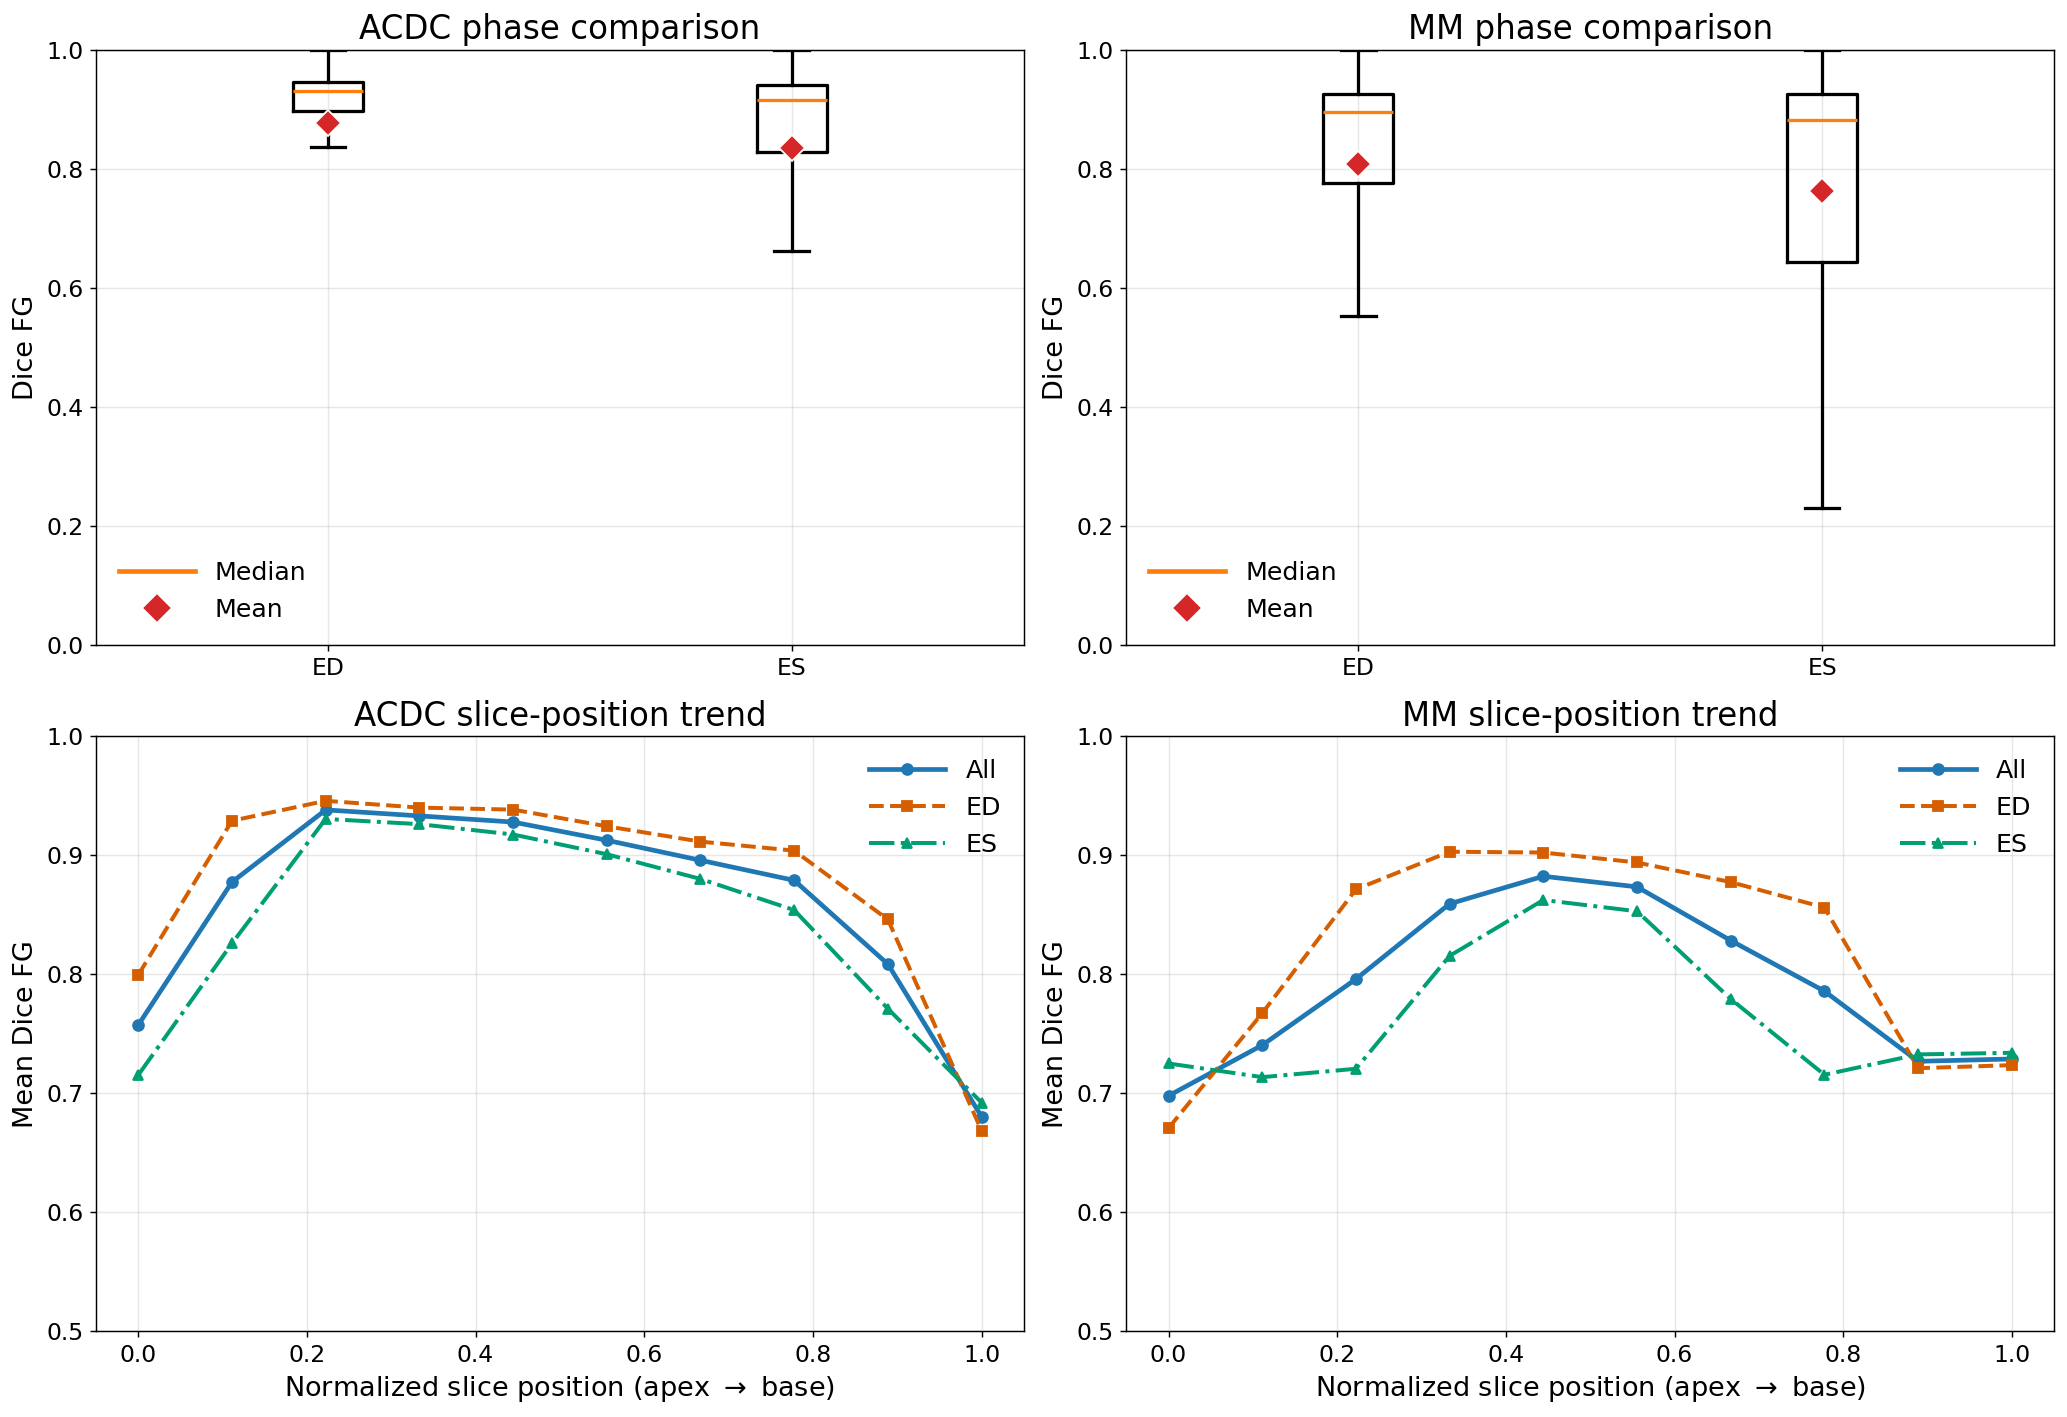

In [80]:
# # ---------- Plots: ED vs ES and slice-position effects ----------
# from matplotlib.lines import Line2D

# TITLE_FS = 18
# LABEL_FS = 15
# TICK_FS = 13
# LEGEND_FS = 14

# fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=130)

# # 1) ED vs ES boxplots per dataset
# box_legend_handles = [
#     Line2D([0], [0], color='#ff7f0e', linewidth=2.6, label='Median'),
#     Line2D([0], [0], marker='D', color='none', markerfacecolor='#d62728', markeredgecolor='white', markersize=12, label='Mean'),
# ]
# for col, ds in enumerate(['acdc', 'mm']):
#     ax = axes[0, col]
#     dsub = df[df['dataset'] == ds]
#     phases = ['ED', 'ES']
#     vals = [dsub[dsub['phase'] == ph]['dice_fg'].values for ph in phases]
#     ax.boxplot(
#         vals,
#         tick_labels=phases,
#         showfliers=False,
#         showmeans=True,
#         meanprops={'marker': 'D', 'markerfacecolor': '#d62728', 'markeredgecolor': 'white', 'markersize': 10},
#         boxprops={'linewidth': 1.8},
#         whiskerprops={'linewidth': 1.8},
#         capprops={'linewidth': 1.8},
#         medianprops={'linewidth': 1.8},
#     )
#     ax.set_title(f'{ds.upper()} phase comparison', fontsize=TITLE_FS)
#     ax.set_ylabel('Dice FG', fontsize=LABEL_FS)
#     ax.set_ylim(0, 1)
#     ax.tick_params(axis='both', labelsize=TICK_FS)
#     ax.grid(alpha=0.3)
#     ax.legend(handles=box_legend_handles, frameon=False, fontsize=LEGEND_FS, loc='lower left', handlelength=3.0)

# # 2) Slice-position trend (binned)
# bins = np.linspace(0, 1, 11)
# phase_style = {
#     'All': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-', 'linewidth': 2.6},
#     'ED': {'color': '#d55e00', 'marker': 's', 'linestyle': '--', 'linewidth': 2.2},
#     'ES': {'color': '#009e73', 'marker': '^', 'linestyle': '-.', 'linewidth': 2.2},
# }
# for col, ds in enumerate(['acdc', 'mm']):
#     ax = axes[1, col]
#     dsub = df[df['dataset'] == ds].copy()
#     dsub['slice_bin'] = pd.cut(dsub['slice_pos'], bins=bins, include_lowest=True)
#     curve_all = dsub.groupby('slice_bin', observed=False)['dice_fg'].mean()
#     centers = np.arange(len(curve_all)) / (len(curve_all) - 1)
#     ax.plot(centers, curve_all.values, label='All', **phase_style['All'])
#     for phase in ['ED', 'ES']:
#         dphase = dsub[dsub['phase'] == phase]
#         curve = dphase.groupby('slice_bin', observed=False)['dice_fg'].mean().reindex(curve_all.index)
#         ax.plot(centers, curve.values, label=phase, **phase_style[phase])
#     ax.set_title(f'{ds.upper()} slice-position trend', fontsize=TITLE_FS)
#     ax.set_xlabel(r'Normalized slice position (apex $\rightarrow$ base)', fontsize=LABEL_FS)
#     ax.set_ylabel('Mean Dice FG', fontsize=LABEL_FS)
#     ax.set_ylim(0.5, 1.0)
#     ax.tick_params(axis='both', labelsize=TICK_FS)
#     ax.grid(alpha=0.3)
#     ax.legend(frameon=False, fontsize=LEGEND_FS, handlelength=3.0)

# plt.tight_layout()
# plt.show()


# ---------- Plots: ED vs ES and slice-position effects ----------
from matplotlib.lines import Line2D

TITLE_FS = 18
LABEL_FS = 15
TICK_FS = 13
LEGEND_FS = 14

fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=130)

# 1) ED vs ES boxplots per dataset
box_legend_handles = [
    Line2D([0], [0], color='#ff7f0e', linewidth=2.6, label='Median'),
    Line2D([0], [0], marker='D', color='none', markerfacecolor='#d62728',
           markeredgecolor='white', markersize=12, label='Mean'),
]

for col, ds in enumerate(['acdc', 'mm']):
    ax = axes[0, col]
    dsub = df[df['dataset'] == ds]
    phases = ['ED', 'ES']
    vals = [dsub[dsub['phase'] == ph]['dice_fg'].values for ph in phases]

    ax.boxplot(
        vals,
        tick_labels=phases,
        showfliers=False,
        showmeans=True,
        meanprops={
            'marker': 'D',
            'markerfacecolor': '#d62728',
            'markeredgecolor': 'white',
            'markersize': 10
        },
        boxprops={'linewidth': 1.8},
        whiskerprops={'linewidth': 1.8},
        capprops={'linewidth': 1.8},
        medianprops={'linewidth': 1.8},
    )

    ax.set_title(f'{ds.upper()} phase comparison', fontsize=TITLE_FS)
    ax.set_ylabel('Dice FG', fontsize=LABEL_FS)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(alpha=0.3)
    ax.legend(
        handles=box_legend_handles,
        frameon=False,
        fontsize=LEGEND_FS,
        loc='lower left',
        handlelength=3.0
    )

# 2) Slice-position trend (binned)
bins = np.linspace(0, 1, 11)
phase_style = {
    'All': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-', 'linewidth': 2.6},
    'ED':  {'color': '#d55e00', 'marker': 's', 'linestyle': '--', 'linewidth': 2.2},
    'ES':  {'color': '#009e73', 'marker': '^', 'linestyle': '-.', 'linewidth': 2.2},
}

for col, ds in enumerate(['acdc', 'mm']):
    ax = axes[1, col]
    dsub = df[df['dataset'] == ds].copy()

    # Reverse slice order for M&M so both datasets run from apex -> base
    if ds == 'mm':
        dsub['slice_pos'] = 1 - dsub['slice_pos']

    dsub['slice_bin'] = pd.cut(dsub['slice_pos'], bins=bins, include_lowest=True)

    curve_all = dsub.groupby('slice_bin', observed=False)['dice_fg'].mean()
    centers = np.arange(len(curve_all)) / (len(curve_all) - 1)

    ax.plot(centers, curve_all.values, label='All', **phase_style['All'])

    for phase in ['ED', 'ES']:
        dphase = dsub[dsub['phase'] == phase]
        curve = dphase.groupby('slice_bin', observed=False)['dice_fg'].mean().reindex(curve_all.index)
        ax.plot(centers, curve.values, label=phase, **phase_style[phase])

    ax.set_title(f'{ds.upper()} slice-position trend', fontsize=TITLE_FS)
    ax.set_xlabel(r'Normalized slice position (apex $\rightarrow$ base)', fontsize=LABEL_FS)
    ax.set_ylabel('Mean Dice FG', fontsize=LABEL_FS)
    ax.set_ylim(0.5, 1.0)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=LEGEND_FS, handlelength=3.0)

plt.tight_layout()
plt.show()

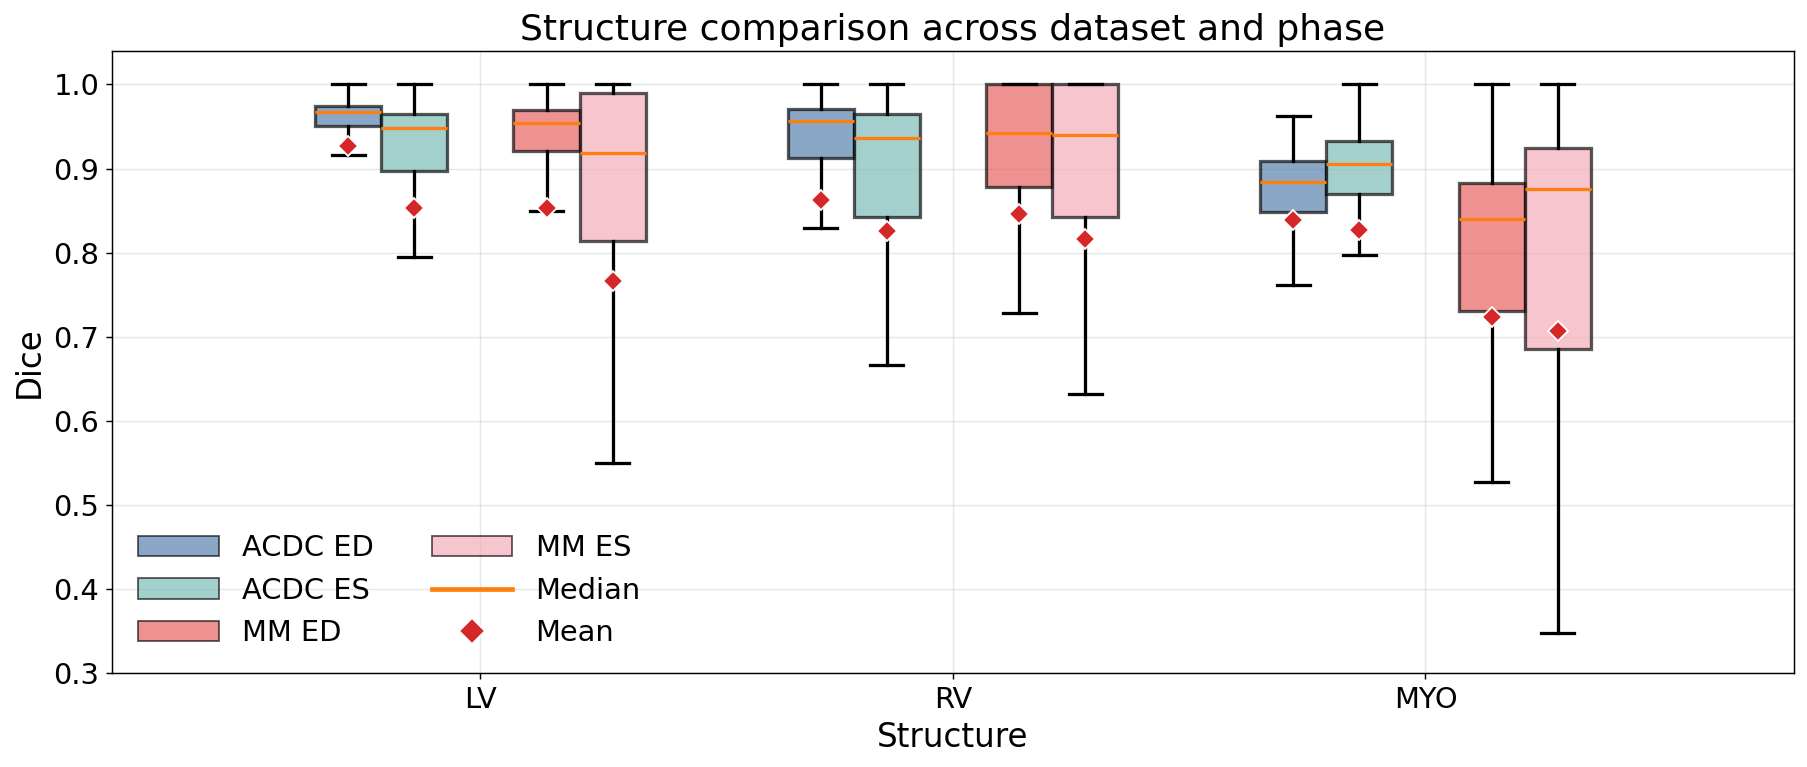

In [10]:
# ---------- Combined structure-wise grouped boxplots ----------
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

TITLE_FS = 20
LABEL_FS = 18
TICK_FS = 16
LEGEND_FS = 16

# Standard cardiac label convention used here: c1=RV, c2=MYO, c3=LV
STRUCTURES = [
    ('LV', 'dice_c3'),
    ('RV', 'dice_c1'),
    ('MYO', 'dice_c2'),
]
GROUPS = [
    ('ACDC ED', 'acdc', 'ED', '#4C78A8'),
    ('ACDC ES', 'acdc', 'ES', '#72B7B2'),
    ('MM ED', 'mm', 'ED', '#E45756'),
    ('MM ES', 'mm', 'ES', '#F2A7B5'),
]

fig, ax = plt.subplots(1, 1, figsize=(14, 6), dpi=130)
box_legend_handles = [
    Patch(facecolor=GROUPS[0][3], edgecolor='black', alpha=0.65, label='ACDC ED'),
    Patch(facecolor=GROUPS[1][3], edgecolor='black', alpha=0.65, label='ACDC ES'),
    Patch(facecolor=GROUPS[2][3], edgecolor='black', alpha=0.65, label='MM ED'),
    Patch(facecolor=GROUPS[3][3], edgecolor='black', alpha=0.65, label='MM ES'),
    Line2D([0], [0], color='#ff7f0e', linewidth=2.6, label='Median'),
    Line2D([0], [0], marker='D', color='none', markerfacecolor='#d62728', markeredgecolor='white', markersize=10, label='Mean'),
]

centers = np.arange(1, len(STRUCTURES) + 1)
offsets = [-0.28, -0.14, 0.14, 0.28]
width = 0.14

for (label, dataset, phase, color), shift in zip(GROUPS, offsets):
    vals = [df[(df['dataset'] == dataset) & (df['phase'] == phase)][col].dropna().values for _, col in STRUCTURES]
    bp = ax.boxplot(
        vals,
        positions=centers + shift,
        widths=width,
        patch_artist=True,
        showfliers=False,
        showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': '#d62728', 'markeredgecolor': 'white', 'markersize': 8},
        boxprops={'linewidth': 1.8},
        whiskerprops={'linewidth': 1.8},
        capprops={'linewidth': 1.8},
        medianprops={'linewidth': 1.8},
    )
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

ax.set_xticks(centers)
ax.set_xticklabels([name for name, _ in STRUCTURES])
ax.set_title('Structure comparison across dataset and phase', fontsize=TITLE_FS)
ax.set_xlabel('Structure', fontsize=LABEL_FS)
ax.set_ylabel('Dice', fontsize=LABEL_FS)
ax.set_ylim(0.3, 1.04)
ax.tick_params(axis='both', labelsize=TICK_FS)
ax.grid(alpha=0.3)
ax.legend(handles=box_legend_handles, frameon=False, fontsize=LEGEND_FS, loc='lower left', handlelength=2.8, ncol=2)

plt.tight_layout()
plt.show()


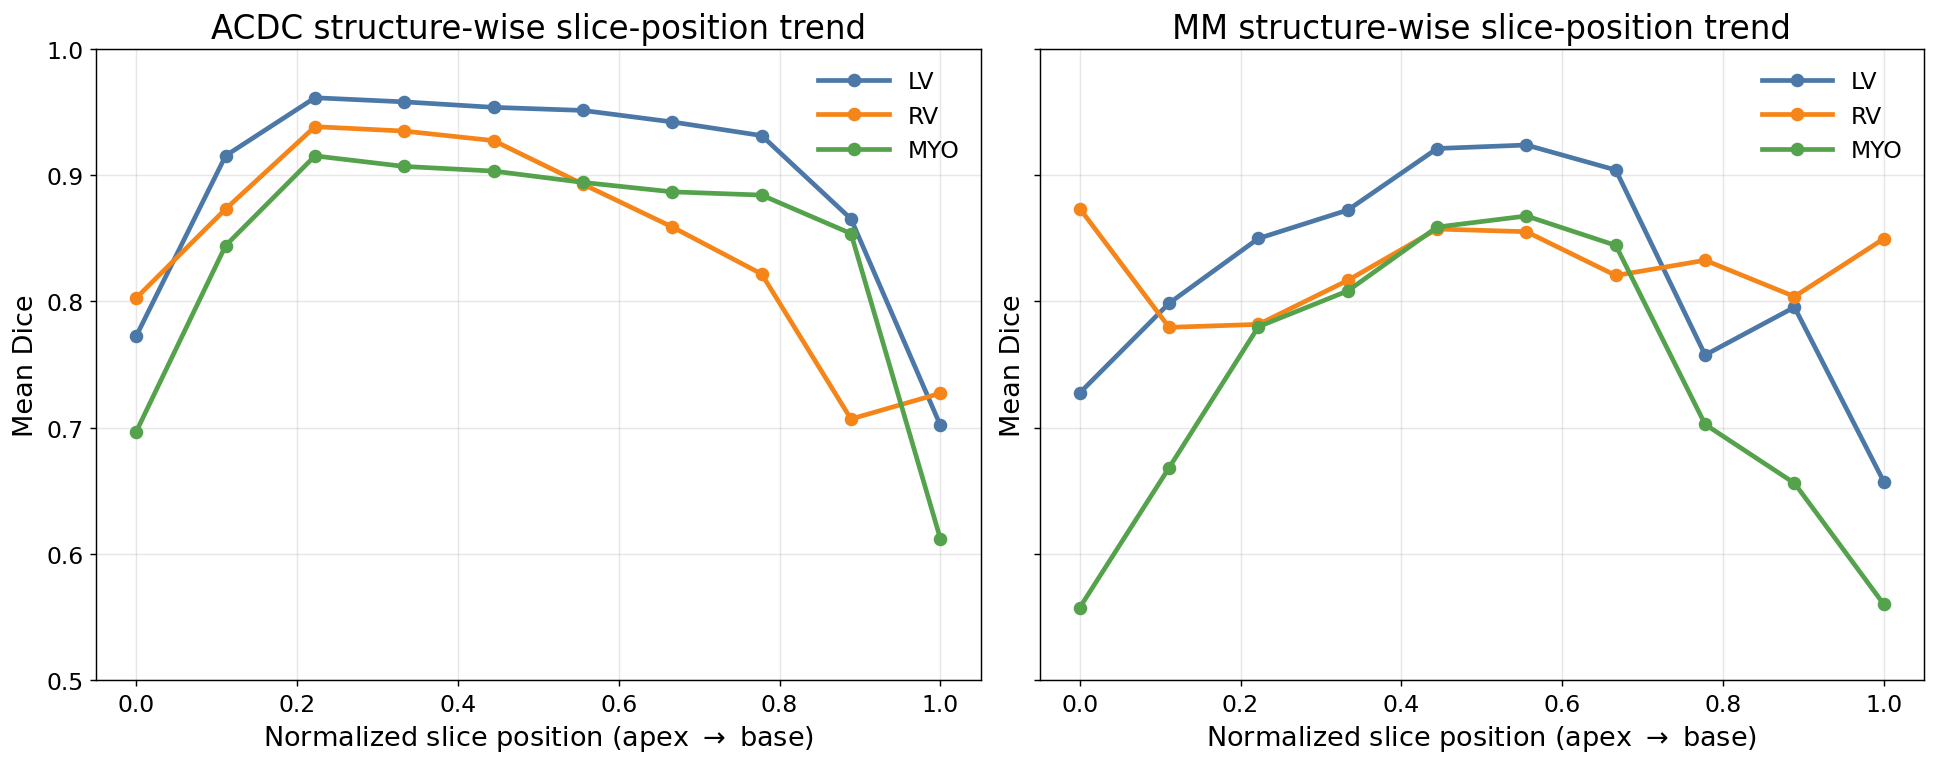

In [11]:
# ---------- Structure-wise slice-position trends ----------
TITLE_FS = 18
LABEL_FS = 15
TICK_FS = 13
LEGEND_FS = 13

STRUCTURES = [
    ('LV', 'dice_c3', '#4C78A8'),
    ('RV', 'dice_c1', '#F58518'),
    ('MYO', 'dice_c2', '#54A24B'),
]
bins = np.linspace(0, 1, 11)
centers = np.arange(10) / 9

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=130, sharey=True)

for ax, ds in zip(axes, ['acdc', 'mm']):
    dsub = df[df['dataset'] == ds].copy()
    dsub['slice_bin'] = pd.cut(dsub['slice_pos'], bins=bins, include_lowest=True)

    for name, col, color in STRUCTURES:
        curve = dsub.groupby('slice_bin', observed=False)[col].mean()
        ax.plot(
            centers,
            curve.values,
            label=name,
            color=color,
            marker='o',
            linewidth=2.6,
            markersize=6.5,
        )

    ax.set_title(f'{ds.upper()} structure-wise slice-position trend', fontsize=TITLE_FS)
    ax.set_xlabel(r'Normalized slice position (apex $\rightarrow$ base)', fontsize=LABEL_FS)
    ax.set_ylabel('Mean Dice', fontsize=LABEL_FS)
    ax.set_ylim(0.5, 1.0)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=LEGEND_FS, handlelength=3.0)

plt.tight_layout()
plt.show()


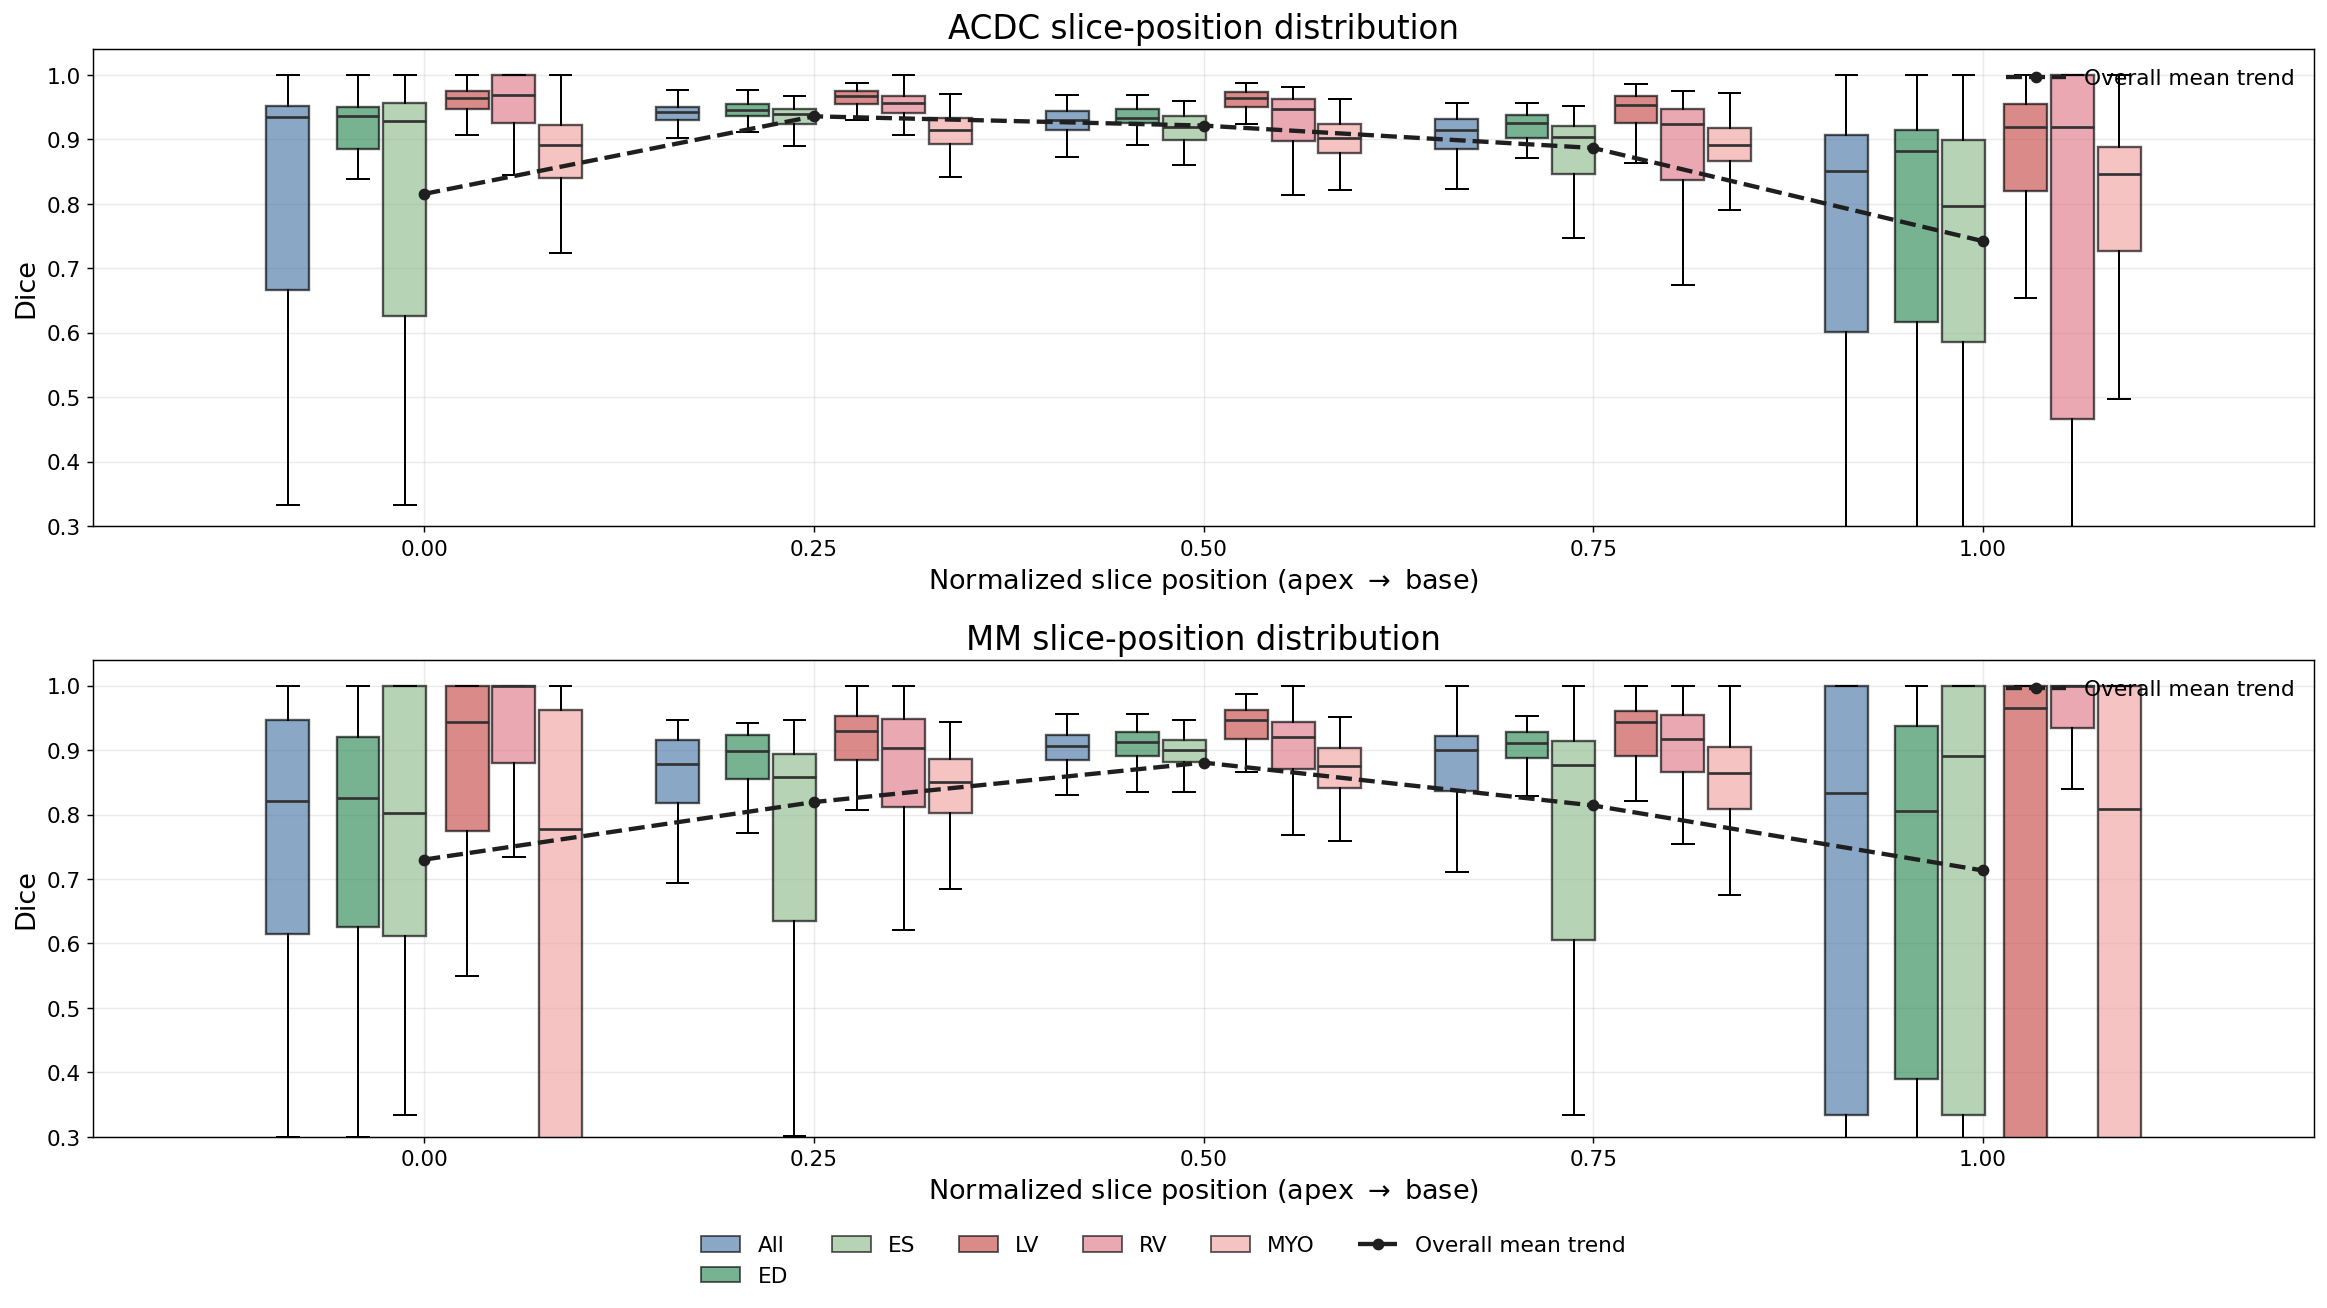

In [12]:
# ---------- Slice-position boxplots by phase and structure ----------
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

TITLE_FS = 18
LABEL_FS = 15
TICK_FS = 12
LEGEND_FS = 12

bins = np.linspace(0, 1, 6)
centers = np.arange(5)
group_specs = [
    ('All', 'dice_fg', '#4C78A8'),
    ('ED', 'ED', '#2E8B57'),
    ('ES', 'ES', '#8FBC8F'),
    ('LV', 'dice_c3', '#C94C4C'),
    ('RV', 'dice_c1', '#E07A8A'),
    ('MYO', 'dice_c2', '#F2A3A3'),
]
offsets = np.array([-0.35, -0.17, -0.05, 0.11, 0.23, 0.35])
width = 0.11

fig, axes = plt.subplots(2, 1, figsize=(18, 10), dpi=130, sharey=True)

for ax, ds in zip(axes, ['acdc', 'mm']):
    dsub = df[df['dataset'] == ds].copy()
    dsub['slice_bin'] = pd.cut(dsub['slice_pos'], bins=bins, include_lowest=True)
    bin_categories = dsub['slice_bin'].cat.categories
    overall_curve = dsub.groupby('slice_bin', observed=False)['dice_fg'].mean()

    for (label, source, color), shift in zip(group_specs, offsets):
        if source in ['ED', 'ES']:
            vals = [
                dsub[(dsub['phase'] == source) & (dsub['slice_bin'] == b)]['dice_fg'].dropna().values
                for b in bin_categories
            ]
        else:
            vals = [dsub[dsub['slice_bin'] == b][source].dropna().values for b in bin_categories]

        bp = ax.boxplot(
            vals,
            positions=centers + shift,
            widths=width,
            patch_artist=True,
            showfliers=False,
            showmeans=False,
            boxprops={'linewidth': 1.3},
            whiskerprops={'linewidth': 1.1},
            capprops={'linewidth': 1.1},
            medianprops={'linewidth': 1.5, 'color': '#333333'},
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.65)

    ax.plot(
        centers,
        overall_curve.values,
        color='#1f1f1f',
        linestyle='--',
        linewidth=2.4,
        marker='o',
        markersize=5.5,
        label='Overall mean trend',
        zorder=5,
    )

    ax.set_title(f'{ds.upper()} slice-position distribution', fontsize=TITLE_FS)
    ax.set_xlabel(r'Normalized slice position (apex $\rightarrow$ base)', fontsize=LABEL_FS)
    ax.set_ylabel('Dice', fontsize=LABEL_FS)
    ax.set_ylim(0.3, 1.04)
    ax.set_xticks(centers)
    ax.set_xticklabels([f'{i/4:.2f}' for i in centers])
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=LEGEND_FS, loc='upper right', handlelength=2.8)

legend_handles = [Patch(facecolor=color, edgecolor='black', alpha=0.65, label=label) for label, _, color in group_specs]
legend_handles.append(Line2D([0], [0], color='#1f1f1f', linestyle='--', linewidth=2.4, marker='o', markersize=5.5, label='Overall mean trend'))
fig.legend(handles=legend_handles, frameon=False, fontsize=LEGEND_FS, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.01), handlelength=1.8)

plt.tight_layout()
fig.subplots_adjust(bottom=0.12, hspace=0.28)
plt.show()


/media/ttoxopeus/tmp/ipykernel_2363268/1150669764.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


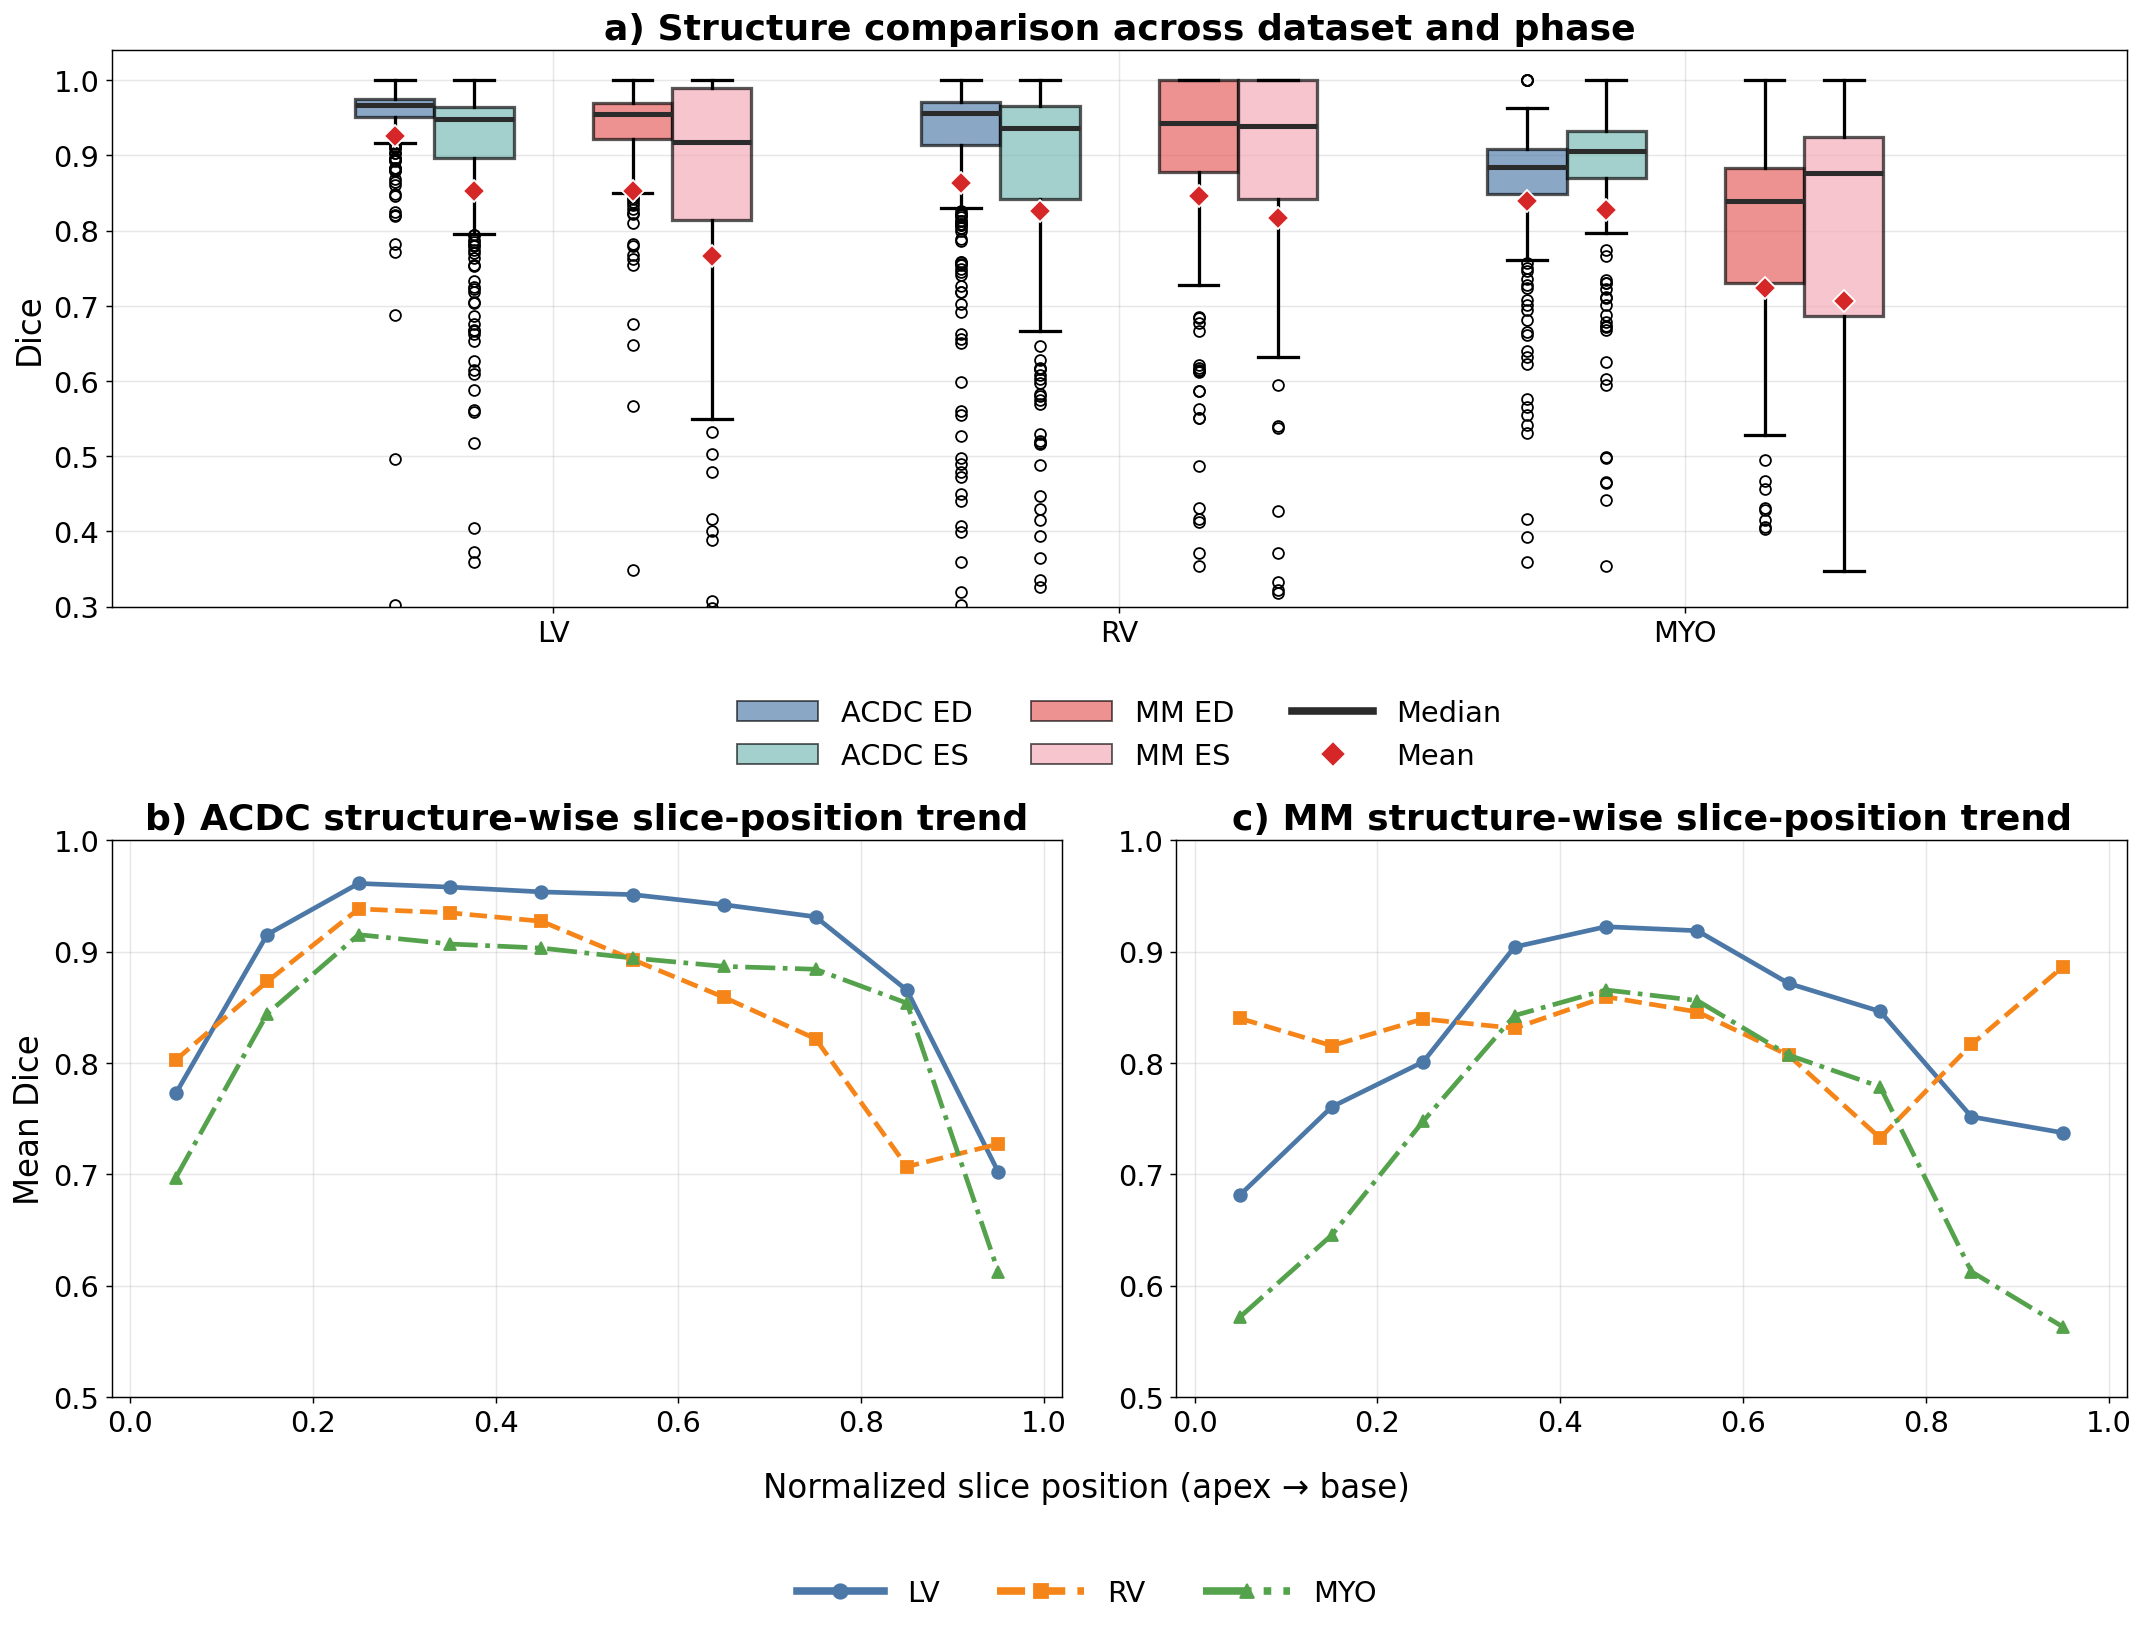

In [81]:
# from matplotlib.lines import Line2D
# from matplotlib.patches import Patch

# TITLE_FS = 20
# LABEL_FS = 18
# TICK_FS = 16
# LEGEND_FS = 16

# fig = plt.figure(figsize=(20, 14), dpi=130)
# gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.42, wspace=0.12)

# # Top wide panel: structure comparison across dataset and phase
# ax_top = fig.add_subplot(gs[0, :])
# structures = ['LV', 'RV', 'MYO']
# datasets = ['ACDC ED', 'ACDC ES', 'MM ED', 'MM ES']
# colors = {
#     'ACDC ED': '#4C78A8',
#     'ACDC ES': '#72B7B2',
#     'MM ED': '#E45756',
#     'MM ES': '#F2A7B5',
# }
# phase_map = {
#     'ACDC ED': ('acdc', 'ED'),
#     'ACDC ES': ('acdc', 'ES'),
#     'MM ED': ('mm', 'ED'),
#     'MM ES': ('mm', 'ES'),
# }
# structure_map = {'LV': 'dice_c3', 'RV': 'dice_c1', 'MYO': 'dice_c2'}

# base_pos = np.arange(len(structures))
# offsets = np.array([-0.28, -0.14, 0.14, 0.28])
# box_width = 0.14

# for offset, label in zip(offsets, datasets):
#     ds, phase = phase_map[label]
#     for i, struct in enumerate(structures):
#         values = df[(df['dataset'] == ds) & (df['phase'] == phase)][structure_map[struct]].dropna().tolist()
#         pos = base_pos[i] + offset
#         ax_top.boxplot(
#             values,
#             positions=[pos],
#             widths=box_width,
#             patch_artist=True,
#             showmeans=True,
#             boxprops=dict(facecolor=colors[label], edgecolor='black', linewidth=1.8, alpha=0.65),
#             medianprops=dict(color='#2B2B2B', linewidth=2.8),
#             whiskerprops=dict(color='black', linewidth=1.8),
#             capprops=dict(color='black', linewidth=1.8),
#             meanprops=dict(marker='D', markerfacecolor='#D62728', markeredgecolor='white', markersize=9),
#         )

# ax_top.set_xticks(base_pos)
# ax_top.set_xticklabels(structures, fontsize=TICK_FS)
# ax_top.set_ylabel('Dice', fontsize=LABEL_FS)
# ax_top.set_title('a) Structure comparison across dataset and phase', fontsize=TITLE_FS, fontweight='bold')
# ax_top.set_ylim(0.3, 1.04)
# ax_top.tick_params(axis='both', labelsize=TICK_FS)
# ax_top.grid(True, alpha=0.3)

# legend_handles = [
#     Patch(facecolor=colors['ACDC ED'], edgecolor='black', alpha=0.65, label='ACDC ED'),
#     Patch(facecolor=colors['ACDC ES'], edgecolor='black', alpha=0.65, label='ACDC ES'),
#     Patch(facecolor=colors['MM ED'], edgecolor='black', alpha=0.65, label='MM ED'),
#     Patch(facecolor=colors['MM ES'], edgecolor='black', alpha=0.65, label='MM ES'),
#     Line2D([0], [0], color='#2B2B2B', linewidth=4.2, label='Median'),
#     Line2D([0], [0], marker='D', color='none', markerfacecolor='#D62728', markeredgecolor='white', markersize=10, label='Mean'),
# ]
# ax_top.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=LEGEND_FS, frameon=False, ncol=3, handlelength=2.8)

# # Bottom row: structure-wise slice-position trends
# structure_lines = [
#     ('LV', 'dice_c3', '#4C78A8', '-', 'o'),
#     ('RV', 'dice_c1', '#F58518', '--', 's'),
#     ('MYO', 'dice_c2', '#54A24B', '-.', '^'),
# ]

# bottom_axes = [
#     (fig.add_subplot(gs[1, 0]), 'acdc', 'b) ACDC structure-wise slice-position trend'),
#     (fig.add_subplot(gs[1, 1]), 'mm', 'c) MM structure-wise slice-position trend'),
# ]

# for idx, (ax, ds, title) in enumerate(bottom_axes):
#     df_ds = df[df['dataset'] == ds].copy()
#     bins = np.linspace(0, 1, 11)
#     centers = (bins[:-1] + bins[1:]) / 2
#     df_ds['slice_bin'] = pd.cut(df_ds['slice_pos'], bins=bins, include_lowest=True, labels=False)

#     for label, col, color, linestyle, marker in structure_lines:
#         y = df_ds.groupby('slice_bin')[col].mean().reindex(range(len(centers)))
#         ax.plot(
#             centers,
#             y.values,
#             marker=marker,
#             linestyle=linestyle,
#             linewidth=2.6,
#             markersize=7,
#             label=label,
#             color=color,
#         )

#     ax.set_title(title, fontsize=TITLE_FS, fontweight='bold')
#     ax.set_xlabel('')
#     ax.set_ylabel('Mean Dice', fontsize=LABEL_FS)
#     ax.set_ylim(0.5, 1.0)
#     ax.set_xlim(-0.02, 1.02)
#     if idx == 1:
#         ax.set_ylabel('')
#     ax.tick_params(axis='both', labelsize=TICK_FS)
#     ax.grid(True, alpha=0.3)
# bottom_legend_handles = [
#     Line2D([0], [0], color='#4C78A8', linestyle='-', marker='o', linewidth=4.2, markersize=8.0, label='LV'),
#     Line2D([0], [0], color='#F58518', linestyle='--', marker='s', linewidth=4.2, markersize=8.0, label='RV'),
#     Line2D([0], [0], color='#54A24B', linestyle='-.', marker='^', linewidth=4.2, markersize=8.0, label='MYO'),
# ]
# fig.text(0.5, 0.085, 'Normalized slice position (apex → base)', ha='center', fontsize=LABEL_FS)
# fig.legend(handles=bottom_legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.01), fontsize=LEGEND_FS, frameon=False, ncol=3, handlelength=3.0)

# plt.tight_layout()
# fig.subplots_adjust(bottom=0.14)
# plt.show()






from matplotlib.lines import Line2D
from matplotlib.patches import Patch

TITLE_FS = 20
LABEL_FS = 18
TICK_FS = 16
LEGEND_FS = 16

fig = plt.figure(figsize=(20, 14), dpi=130)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.42, wspace=0.12)

# Top wide panel: structure comparison across dataset and phase
ax_top = fig.add_subplot(gs[0, :])
structures = ['LV', 'RV', 'MYO']
datasets = ['ACDC ED', 'ACDC ES', 'MM ED', 'MM ES']
colors = {
    'ACDC ED': '#4C78A8',
    'ACDC ES': '#72B7B2',
    'MM ED': '#E45756',
    'MM ES': '#F2A7B5',
}
phase_map = {
    'ACDC ED': ('acdc', 'ED'),
    'ACDC ES': ('acdc', 'ES'),
    'MM ED': ('mm', 'ED'),
    'MM ES': ('mm', 'ES'),
}
structure_map = {'LV': 'dice_c3', 'RV': 'dice_c1', 'MYO': 'dice_c2'}

base_pos = np.arange(len(structures))
offsets = np.array([-0.28, -0.14, 0.14, 0.28])
box_width = 0.14

for offset, label in zip(offsets, datasets):
    ds, phase = phase_map[label]
    for i, struct in enumerate(structures):
        values = df[(df['dataset'] == ds) & (df['phase'] == phase)][structure_map[struct]].dropna().tolist()
        pos = base_pos[i] + offset
        ax_top.boxplot(
            values,
            positions=[pos],
            widths=box_width,
            patch_artist=True,
            showmeans=True,
            boxprops=dict(facecolor=colors[label], edgecolor='black', linewidth=1.8, alpha=0.65),
            medianprops=dict(color='#2B2B2B', linewidth=2.8),
            whiskerprops=dict(color='black', linewidth=1.8),
            capprops=dict(color='black', linewidth=1.8),
            meanprops=dict(marker='D', markerfacecolor='#D62728', markeredgecolor='white', markersize=9),
        )

ax_top.set_xticks(base_pos)
ax_top.set_xticklabels(structures, fontsize=TICK_FS)
ax_top.set_ylabel('Dice', fontsize=LABEL_FS)
ax_top.set_title('a) Structure comparison across dataset and phase', fontsize=TITLE_FS, fontweight='bold')
ax_top.set_ylim(0.3, 1.04)
ax_top.tick_params(axis='both', labelsize=TICK_FS)
ax_top.grid(True, alpha=0.3)

legend_handles = [
    Patch(facecolor=colors['ACDC ED'], edgecolor='black', alpha=0.65, label='ACDC ED'),
    Patch(facecolor=colors['ACDC ES'], edgecolor='black', alpha=0.65, label='ACDC ES'),
    Patch(facecolor=colors['MM ED'], edgecolor='black', alpha=0.65, label='MM ED'),
    Patch(facecolor=colors['MM ES'], edgecolor='black', alpha=0.65, label='MM ES'),
    Line2D([0], [0], color='#2B2B2B', linewidth=4.2, label='Median'),
    Line2D([0], [0], marker='D', color='none', markerfacecolor='#D62728', markeredgecolor='white', markersize=10, label='Mean'),
]
ax_top.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    fontsize=LEGEND_FS,
    frameon=False,
    ncol=3,
    handlelength=2.8
)

# Bottom row: structure-wise slice-position trends
structure_lines = [
    ('LV', 'dice_c3', '#4C78A8', '-', 'o'),
    ('RV', 'dice_c1', '#F58518', '--', 's'),
    ('MYO', 'dice_c2', '#54A24B', '-.', '^'),
]

bottom_axes = [
    (fig.add_subplot(gs[1, 0]), 'acdc', 'b) ACDC structure-wise slice-position trend'),
    (fig.add_subplot(gs[1, 1]), 'mm', 'c) MM structure-wise slice-position trend'),
]

for idx, (ax, ds, title) in enumerate(bottom_axes):
    df_ds = df[df['dataset'] == ds].copy()

    # Reverse slice order for M&M so both datasets run from apex -> base
    if ds == 'mm':
        df_ds['slice_pos'] = 1 - df_ds['slice_pos']

    bins = np.linspace(0, 1, 11)
    centers = (bins[:-1] + bins[1:]) / 2
    df_ds['slice_bin'] = pd.cut(df_ds['slice_pos'], bins=bins, include_lowest=True, labels=False)

    for label, col, color, linestyle, marker in structure_lines:
        y = df_ds.groupby('slice_bin')[col].mean().reindex(range(len(centers)))
        ax.plot(
            centers,
            y.values,
            marker=marker,
            linestyle=linestyle,
            linewidth=2.6,
            markersize=7,
            label=label,
            color=color,
        )

    ax.set_title(title, fontsize=TITLE_FS, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean Dice', fontsize=LABEL_FS)
    ax.set_ylim(0.5, 1.0)
    ax.set_xlim(-0.02, 1.02)
    if idx == 1:
        ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)

bottom_legend_handles = [
    Line2D([0], [0], color='#4C78A8', linestyle='-', marker='o', linewidth=4.2, markersize=8.0, label='LV'),
    Line2D([0], [0], color='#F58518', linestyle='--', marker='s', linewidth=4.2, markersize=8.0, label='RV'),
    Line2D([0], [0], color='#54A24B', linestyle='-.', marker='^', linewidth=4.2, markersize=8.0, label='MYO'),
]
fig.text(0.5, 0.085, 'Normalized slice position (apex → base)', ha='center', fontsize=LABEL_FS)
fig.legend(
    handles=bottom_legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    fontsize=LEGEND_FS,
    frameon=False,
    ncol=3,
    handlelength=3.0
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.14)
plt.show()


In [146]:
# ---------- Example-slice selection helpers ----------
from matplotlib.lines import Line2D

CLASS_INFO = [
    ('RV', 1, '#F58518'),
    ('MYO', 2, '#54A24B'),
    ('LV', 3, '#4C78A8'),
]

# Optional manual case selection per dataset. Set to None for automatic selection.
EXAMPLE_CASES = {
    'acdc': "patient107",
    'mm': "patient103",
}

# Set to 'ED' or 'ES' to force one phase, or None to allow both.
EXAMPLE_PHASE = 'ED'

# Manual slice selection (0-based indices) for the representative panel.
# Set entries to None to use automatic defaults.
EXAMPLE_MANUAL_SLICES = {
    'acdc': {'basal': None, 'middle': None, 'apex': None},
    'mm': {'basal': 15, 'middle': None, 'apex': 0},
}

# Cropping options for the visualization cells below.
# Set EXAMPLE_CROP = None to disable cropping.
# Set EXAMPLE_CROP = 'auto' to crop to the foreground union with padding.
EXAMPLE_CROP = 'auto'
EXAMPLE_CROP_PADDING = 20
EXAMPLE_CROP_MIN_SIZE = 96
# Set to a fixed (height, width) to force identical crop size across examples.
EXAMPLE_CROP_FIXED_SIZE = (114, 114)
SHOW_ERROR_OVERLAY = True

EXAMPLE_MODEL_CACHE = {}
EXAMPLE_CASE_CACHE = {}


def get_example_model(dataset: str):
    if dataset not in EXAMPLE_MODEL_CACHE:
        model, _ = load_model_from_run_summary(DATASET_CONFIGS[dataset]['run_summary'], DEVICE)
        EXAMPLE_MODEL_CACHE[dataset] = model
    return EXAMPLE_MODEL_CACHE[dataset]


@torch.no_grad()
def load_case_predictions(dataset: str, case_id: str, phase: str):
    cache_key = (dataset, case_id, phase)
    if cache_key in EXAMPLE_CASE_CACHE:
        return EXAMPLE_CASE_CACHE[cache_key]

    cfg = DATASET_CONFIGS[dataset]
    model = get_example_model(dataset)

    row0 = df[(df['dataset'] == dataset) & (df['case_id'] == case_id) & (df['phase'] == phase)].iloc[0]
    img_vol = nib.load(str(row0['img_path'])).get_fdata()
    lbl_vol = nib.load(str(row0['lbl_path'])).get_fdata()

    axis = int(cfg.get('slice_axis', 2))
    n_slices = int(lbl_vol.shape[axis])
    slices = []

    with torch.no_grad():
        for s in range(n_slices):
            img_slice = np.take(img_vol, s, axis=axis)
            lbl_slice = np.take(lbl_vol, s, axis=axis).astype(np.int64)

            x = preprocess_image_slice(img_slice, target_size=cfg['target_size'], normalize=True)
            y = preprocess_label_slice(lbl_slice, target_size=cfg['target_size'])
            logits = model(x.unsqueeze(0).to(DEVICE))
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
            gt = y.cpu().numpy()
            d = dice_per_class(pred, gt, num_classes=cfg['num_classes'])
            dice_fg = float(np.mean([d[c] for c in range(1, cfg['num_classes'])]))

            slices.append({
                'dataset': dataset,
                'case_id': case_id,
                'phase': phase,
                'slice_idx': s,
                'num_slices': n_slices,
                'slice_pos': s / max(1, n_slices - 1),
                'img': x.squeeze(0).cpu().numpy(),
                'gt': y.cpu().numpy(),
                'pred': pred,
                'dice_fg': dice_fg,
            })

    EXAMPLE_CASE_CACHE[cache_key] = slices
    return slices


def crop_example(img, gt, pred, padding=20, min_size=96, fixed_size=None):
    mask = (gt > 0) | (pred > 0)
    if not mask.any():
        return img, gt, pred

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1

    cy = (y0 + y1) // 2
    cx = (x0 + x1) // 2

    if fixed_size is None:
        fixed_size = EXAMPLE_CROP_FIXED_SIZE

    if fixed_size is not None:
        h, w = fixed_size
    else:
        h = max(y1 - y0 + 2 * padding, min_size)
        w = max(x1 - x0 + 2 * padding, min_size)

    h = min(h, img.shape[0])
    w = min(w, img.shape[1])

    y0 = max(0, cy - h // 2)
    x0 = max(0, cx - w // 2)
    y1 = min(img.shape[0], y0 + h)
    x1 = min(img.shape[1], x0 + w)
    y0 = max(0, y1 - h)
    x0 = max(0, x1 - w)

    return img[y0:y1, x0:x1], gt[y0:y1, x0:x1], pred[y0:y1, x0:x1]


def select_example_case(dataset: str, phase: str | None = None, case_id: str | None = None):
    dsub = df[(df['dataset'] == dataset) & (df['gt_fg_pixels'] > 0)].copy()
    if phase is not None:
        dsub = dsub[dsub['phase'] == phase].copy()
    if case_id is not None:
        dsub = dsub[dsub['case_id'] == case_id].copy()
        if dsub.empty:
            raise ValueError(f'No rows found for dataset={dataset}, case_id={case_id}, phase={phase}.')

    candidate_cases = sorted(dsub['case_id'].unique())
    if not candidate_cases:
        raise ValueError(f'No candidate cases found for {dataset}, phase={phase}.')

    best = None
    for cid in candidate_cases:
        case_df = dsub[dsub['case_id'] == cid]
        score = abs(case_df['slice_pos'].median() - 0.5) + abs(case_df['dice_fg'].median() - dsub['dice_fg'].median())
        if best is None or score < best[0]:
            best = (score, cid)
    return best[1]


def build_example_df():
    rows = []
    slice_types = ['basal', 'middle', 'apex']
    for dataset in ['acdc', 'mm']:
        selected_case = select_example_case(dataset, EXAMPLE_PHASE, EXAMPLE_CASES.get(dataset))
        case_slices = load_case_predictions(dataset, selected_case, EXAMPLE_PHASE)
        n_slices = len(case_slices)
        manual = EXAMPLE_MANUAL_SLICES.get(dataset, {})

        default_indices = {
            'basal': 0,
            'middle': n_slices // 2,
            'apex': n_slices - 1,
        }

        for slice_type in slice_types:
            idx = manual.get(slice_type)
            if idx is None:
                idx = default_indices[slice_type]
            idx = int(max(0, min(n_slices - 1, idx)))
            item = case_slices[idx]
            rows.append({
                'dataset': item['dataset'].upper(),
                'dataset_key': item['dataset'],
                'slice_type': slice_type,
                'case_id': item['case_id'],
                'phase': item['phase'],
                'slice_idx': item['slice_idx'],
                'slice': f"{item['slice_idx'] + 1}/{item['num_slices']}",
                'slice_pos': round(float(item['slice_pos']), 3),
                'dice_fg': round(float(item['dice_fg']), 3),
            })
    return pd.DataFrame(rows)


example_df = build_example_df()
display(example_df)




,dataset,dataset_key,slice_type,case_id,phase,slice_idx,slice,slice_pos,dice_fg
0,ACDC,acdc,basal,patient107,ED,0,1/9,0.0,0.611
1,ACDC,acdc,middle,patient107,ED,4,5/9,0.5,0.937
2,ACDC,acdc,apex,patient107,ED,8,9/9,1.0,0.410
3,MM,mm,basal,patient103,ED,12,13/13,1.0,0.333
4,MM,mm,middle,patient103,ED,6,7/13,0.5,0.923
5,MM,mm,apex,patient103,ED,0,1/13,0.0,0.667


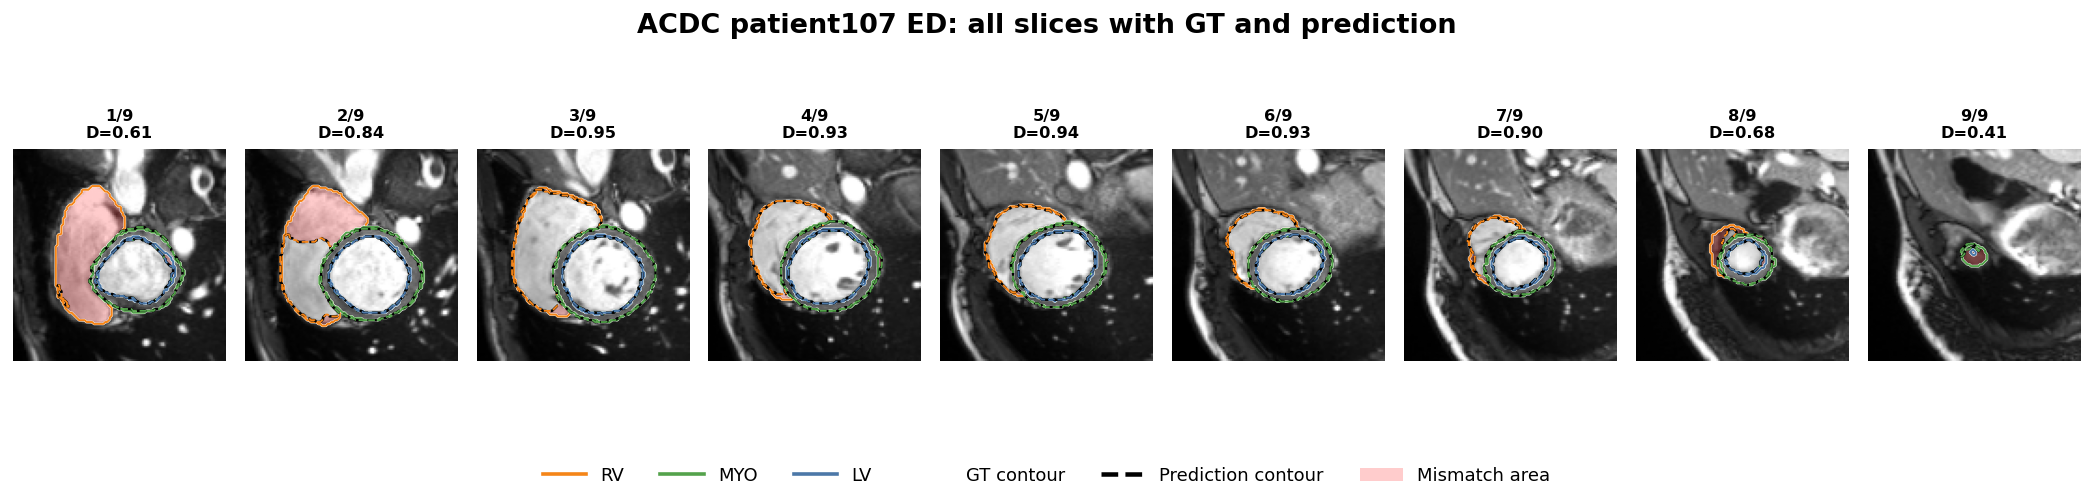

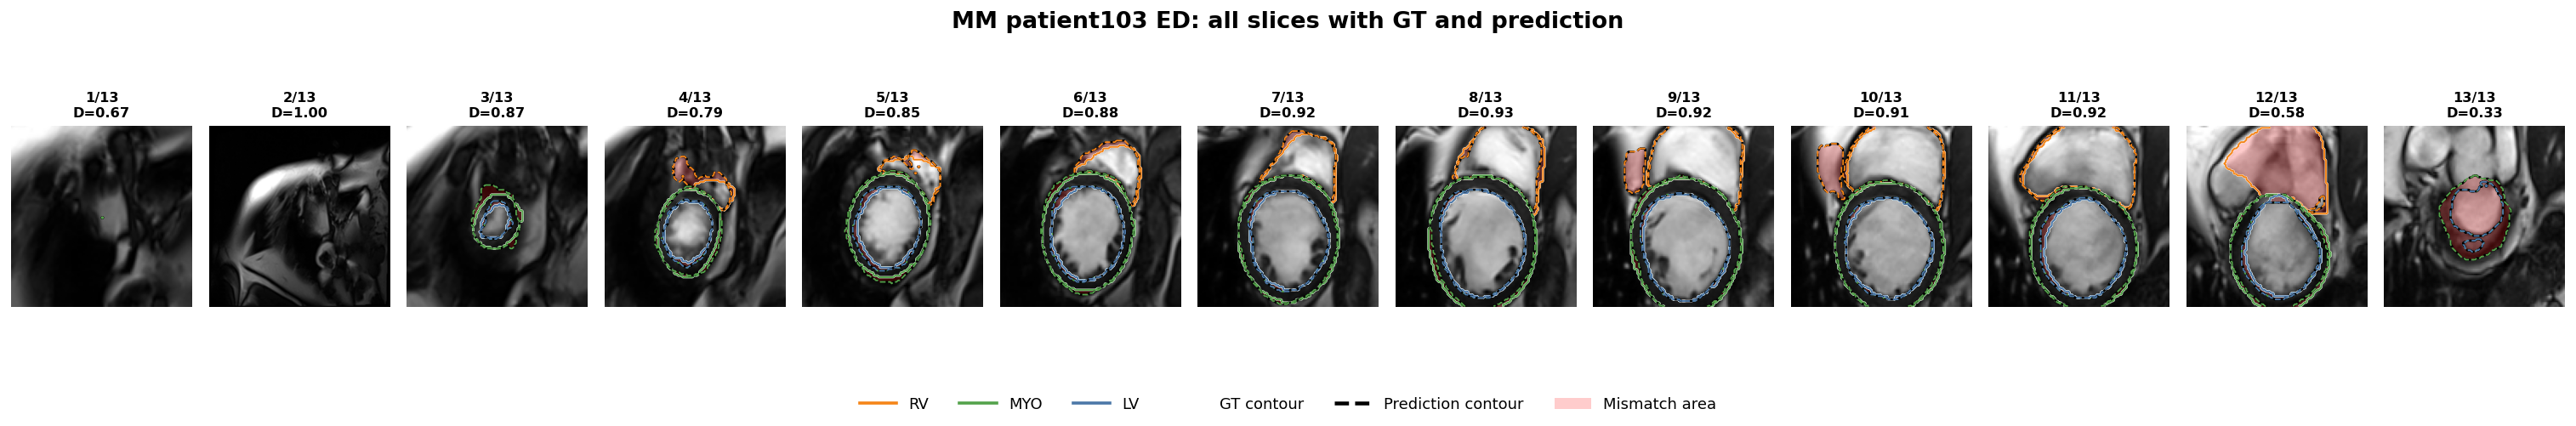

In [147]:
# ---------- Full-slice overview for the selected example patients ----------
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

selected_cases = (
    example_df[['dataset_key', 'case_id', 'phase']]
    .drop_duplicates()
    .sort_values(['dataset_key'])
    .to_dict('records')
)

for case in selected_cases:
    dataset = case['dataset_key']
    case_id = case['case_id']
    phase = case['phase']
    slices = load_case_predictions(dataset, case_id, phase)
    n_slices = len(slices)

    fig, axes = plt.subplots(1, n_slices, figsize=(max(16, 1.8 * n_slices), 3.8), dpi=130)
    if n_slices == 1:
        axes = [axes]

    for ax, item in zip(axes, slices):
        img, gt, pred = item['img'], item['gt'], item['pred']
        if EXAMPLE_CROP == 'auto':
            img, gt, pred = crop_example(
                img,
                gt,
                pred,
                padding=EXAMPLE_CROP_PADDING,
                min_size=EXAMPLE_CROP_MIN_SIZE,
            )

        ax.imshow(img, cmap='gray')

        if SHOW_ERROR_OVERLAY:
            error_mask = ((gt > 0) | (pred > 0)) & (gt != pred)
            if error_mask.any():
                error_rgba = np.zeros((*error_mask.shape, 4), dtype=float)
                error_rgba[..., 0] = 1.0
                error_rgba[..., 3] = error_mask.astype(float) * 0.20
                ax.imshow(error_rgba)

        for _, cls_idx, color in CLASS_INFO:
            gt_mask = (gt == cls_idx).astype(float)
            pred_mask = (pred == cls_idx).astype(float)
            if gt_mask.any():
                ax.contour(gt_mask, levels=[0.5], colors=['white'], linewidths=1.5)
                ax.contour(gt_mask, levels=[0.5], colors=[color], linewidths=1.1)
            if pred_mask.any():
                ax.contour(pred_mask, levels=[0.5], colors=['black'], linewidths=1.4, linestyles='--')
                ax.contour(pred_mask, levels=[0.5], colors=[color], linewidths=1.0, linestyles='--')

        ax.set_title(
            f"{item['slice_idx'] + 1}/{item['num_slices']}\nD={item['dice_fg']:.2f}",
            fontsize=9,
            fontweight='bold',
        )
        ax.axis('off')

    class_handles = [Line2D([0], [0], color=color, linewidth=2.0, label=label) for label, _, color in CLASS_INFO]
    style_handles = [
        Line2D([0], [0], color='white', linewidth=2.5, linestyle='-', label='GT contour'),
        Line2D([0], [0], color='black', linewidth=2.5, linestyle='--', label='Prediction contour'),
    ]
    if SHOW_ERROR_OVERLAY:
        style_handles.append(Patch(facecolor=(1, 0, 0, 0.20), edgecolor='none', label='Mismatch area'))

    fig.legend(handles=class_handles + style_handles, loc='lower center', ncol=6, frameon=False, fontsize=10, handlelength=2.4)
    fig.suptitle(
        f"{dataset.upper()} {case_id} {phase}: all slices with GT and prediction",
        fontsize=15,
        fontweight='bold',
    )
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.18, top=0.80)
    plt.show()



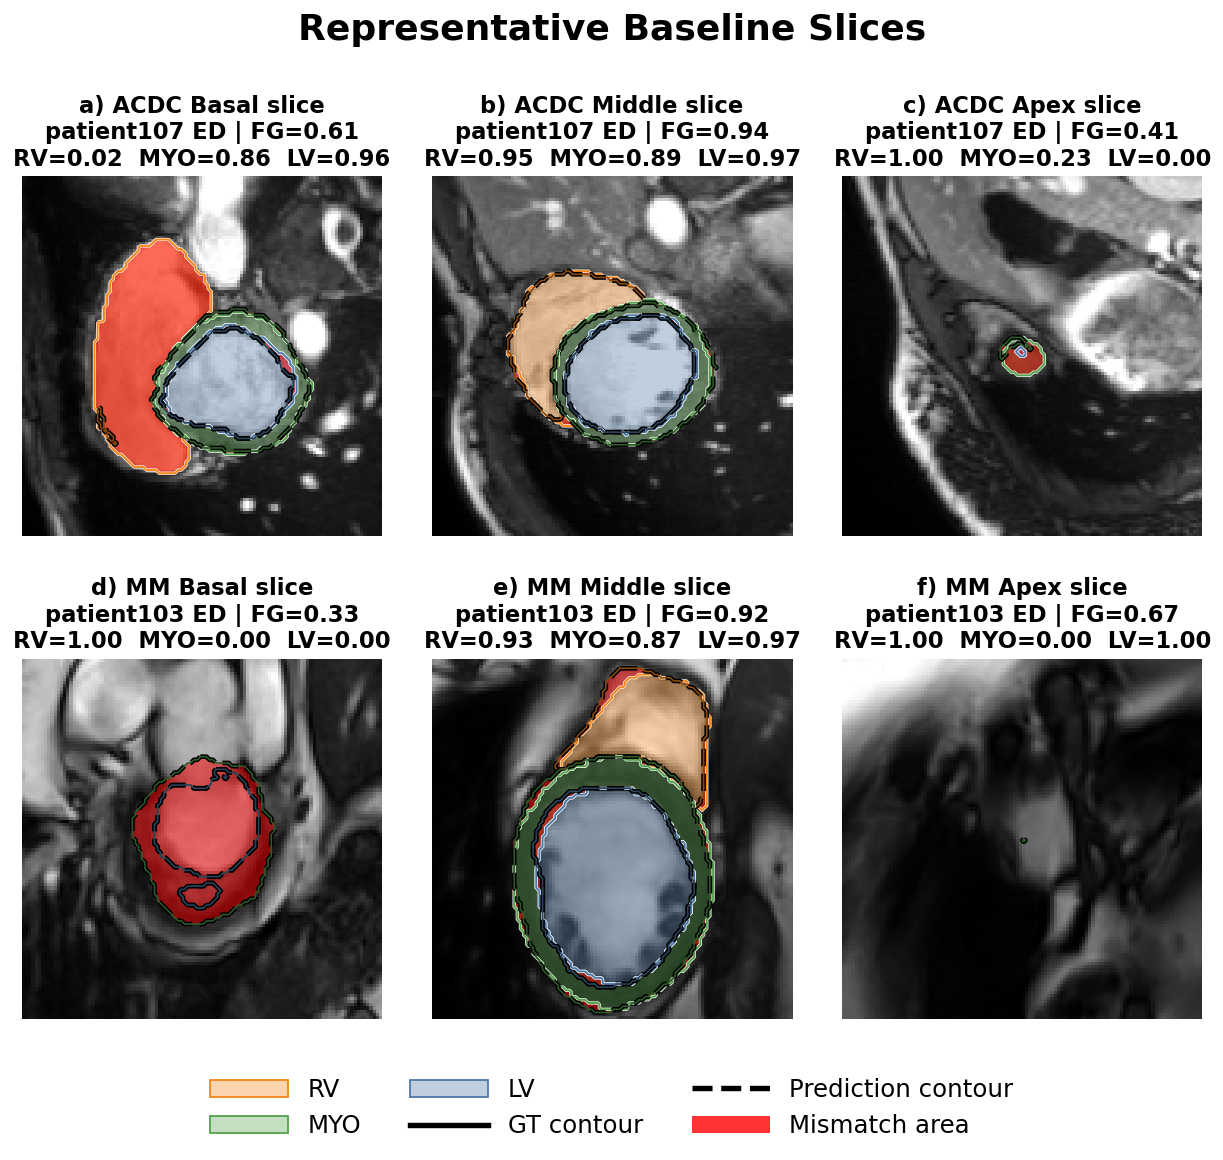

In [167]:
# ---------- Representative example slices with GT and prediction ----------
selected_rows = []
for _, meta in example_df.iterrows():
    case_slices = load_case_predictions(meta['dataset_key'], meta['case_id'], meta['phase'])
    selected_rows.append((meta['slice_type'], case_slices[int(meta['slice_idx'])]))

fig, axes = plt.subplots(2, 3, figsize=(14.5, 9), dpi=130)
slice_order = ['basal', 'middle', 'apex']
dataset_order = ['acdc', 'mm']
row_lookup = {(item['dataset'], slice_type): item for slice_type, item in selected_rows}
panel_letters = ['a', 'b', 'c', 'd', 'e', 'f']
panel_idx = 0

for r, dataset in enumerate(dataset_order):
    for c, slice_type in enumerate(slice_order):
        ax = axes[r, c]
        row = row_lookup[(dataset, slice_type)]
        img, gt, pred = row['img'], row['gt'], row['pred']

        if EXAMPLE_CROP == 'auto':
            img, gt, pred = crop_example(
                img,
                gt,
                pred,
                padding=EXAMPLE_CROP_PADDING,
                min_size=EXAMPLE_CROP_MIN_SIZE,
            )

        d = dice_per_class(pred, gt, num_classes=4)

        ax.imshow(img, cmap='gray')

        for _, cls_idx, color in CLASS_INFO:
            gt_mask_bool = (gt == cls_idx)
            if gt_mask_bool.any():
                gt_rgba = np.zeros((*gt_mask_bool.shape, 4), dtype=float)
                gt_rgba[..., 0] = int(color[1:3], 16) / 255.0
                gt_rgba[..., 1] = int(color[3:5], 16) / 255.0
                gt_rgba[..., 2] = int(color[5:7], 16) / 255.0
                gt_rgba[..., 3] = gt_mask_bool.astype(float) * 0.35
                ax.imshow(gt_rgba)

        if SHOW_ERROR_OVERLAY:
            error_mask = ((gt > 0) | (pred > 0)) & (gt != pred)
            if error_mask.any():
                error_rgba = np.zeros((*error_mask.shape, 4), dtype=float)
                error_rgba[..., 0] = 1.0
                error_rgba[..., 3] = error_mask.astype(float) * 0.5
                ax.imshow(error_rgba)

        for _, cls_idx, color in CLASS_INFO:
            gt_mask = (gt == cls_idx).astype(float)
            pred_mask = (pred == cls_idx).astype(float)
            darker = (
                int(color[1:3], 16) / 255.0 * 0.55,
                int(color[3:5], 16) / 255.0 * 0.55,
                int(color[5:7], 16) / 255.0 * 0.55,
            )
            if gt_mask.any():
                ax.contour(gt_mask, levels=[0.5], colors=['white'], linewidths=1.8)
                ax.contour(gt_mask, levels=[0.5], colors=[color], linewidths=1.1)
            if pred_mask.any():
                ax.contour(pred_mask, levels=[0.5], colors=['black'], linewidths=2.6, linestyles='--')
                ax.contour(pred_mask, levels=[0.5], colors=[darker], linewidths=0.9)

        ax.set_title(
            f"{panel_letters[panel_idx]}) {dataset.upper()} {slice_type.capitalize()} slice\n"
            f"{row['case_id']} {row['phase']} | FG={row['dice_fg']:.2f}\n"
            f"RV={d[1]:.2f}  MYO={d[2]:.2f}  LV={d[3]:.2f}",
            fontsize=12.5,
            fontweight='bold',
        )
        panel_idx += 1
        ax.axis('off')

from matplotlib.patches import Patch
class_handles = [
    Patch(facecolor=(int(color[1:3], 16) / 255.0, int(color[3:5], 16) / 255.0, int(color[5:7], 16) / 255.0, 0.35), edgecolor=color, label=label)
    for label, _, color in CLASS_INFO
]
style_handles = [
    Line2D([0], [0], color='black', linewidth=3.0, linestyle='-', label='GT contour'),
    Line2D([0], [0], color='black', linewidth=3.0, linestyle='--', label='Prediction contour'),
]
if SHOW_ERROR_OVERLAY:
    style_handles.append(Patch(facecolor=(1, 0, 0, 0.8), edgecolor='none', label='Mismatch area'))

fig.legend(handles=class_handles + style_handles, loc='lower center', ncol=3, frameon=False, fontsize=13.5, handlelength=3.2)
fig.suptitle('Representative Baseline Slices', fontsize=20, fontweight='bold')
plt.tight_layout()
fig.subplots_adjust(bottom=0.12, top=0.84, wspace=-0.6, hspace=0.34)
plt.show()








In [72]:
# ---------- RV absence on first and last slice ----------
rv_class_idx = 1  # RV
rows = []

for dataset in ['acdc', 'mm']:
    dsub = df[df['dataset'] == dataset].copy()
    total_cases = dsub['case_id'].nunique()

    first_rows = dsub.loc[dsub.groupby('case_id')['slice_idx'].idxmin()].copy()
    last_rows = dsub.loc[dsub.groupby('case_id')['slice_idx'].idxmax()].copy()

    first_absent = int((first_rows[f'dice_c{rv_class_idx}'] == 1.0).sum())
    last_absent = int((last_rows[f'dice_c{rv_class_idx}'] == 1.0).sum())

    # For truly absent GT slices, the GT foreground pixels for RV should be zero.
    # Re-check directly from labels for robustness.
    def rv_absent_in_gt(row):
        lbl_vol = nib.load(str(row['lbl_path'])).get_fdata()
        axis = int(DATASET_CONFIGS[dataset].get('slice_axis', 2))
        lbl_slice = np.take(lbl_vol, int(row['slice_idx']), axis=axis).astype(np.int64)
        return int((lbl_slice == rv_class_idx).sum()) == 0

    first_absent_gt = int(first_rows.apply(rv_absent_in_gt, axis=1).sum())
    last_absent_gt = int(last_rows.apply(rv_absent_in_gt, axis=1).sum())

    rows.append({
        'dataset': dataset.upper(),
        'total_cases': total_cases,
        'RV absent in GT on first slice': first_absent_gt,
        'RV absent in GT on last slice': last_absent_gt,
    })

rv_absence_df = pd.DataFrame(rows)
display(rv_absence_df)



,dataset,total_cases,RV absent in GT on first slice,RV absent in GT on last slice
0,ACDC,50,20,28
1,MM,34,32,34


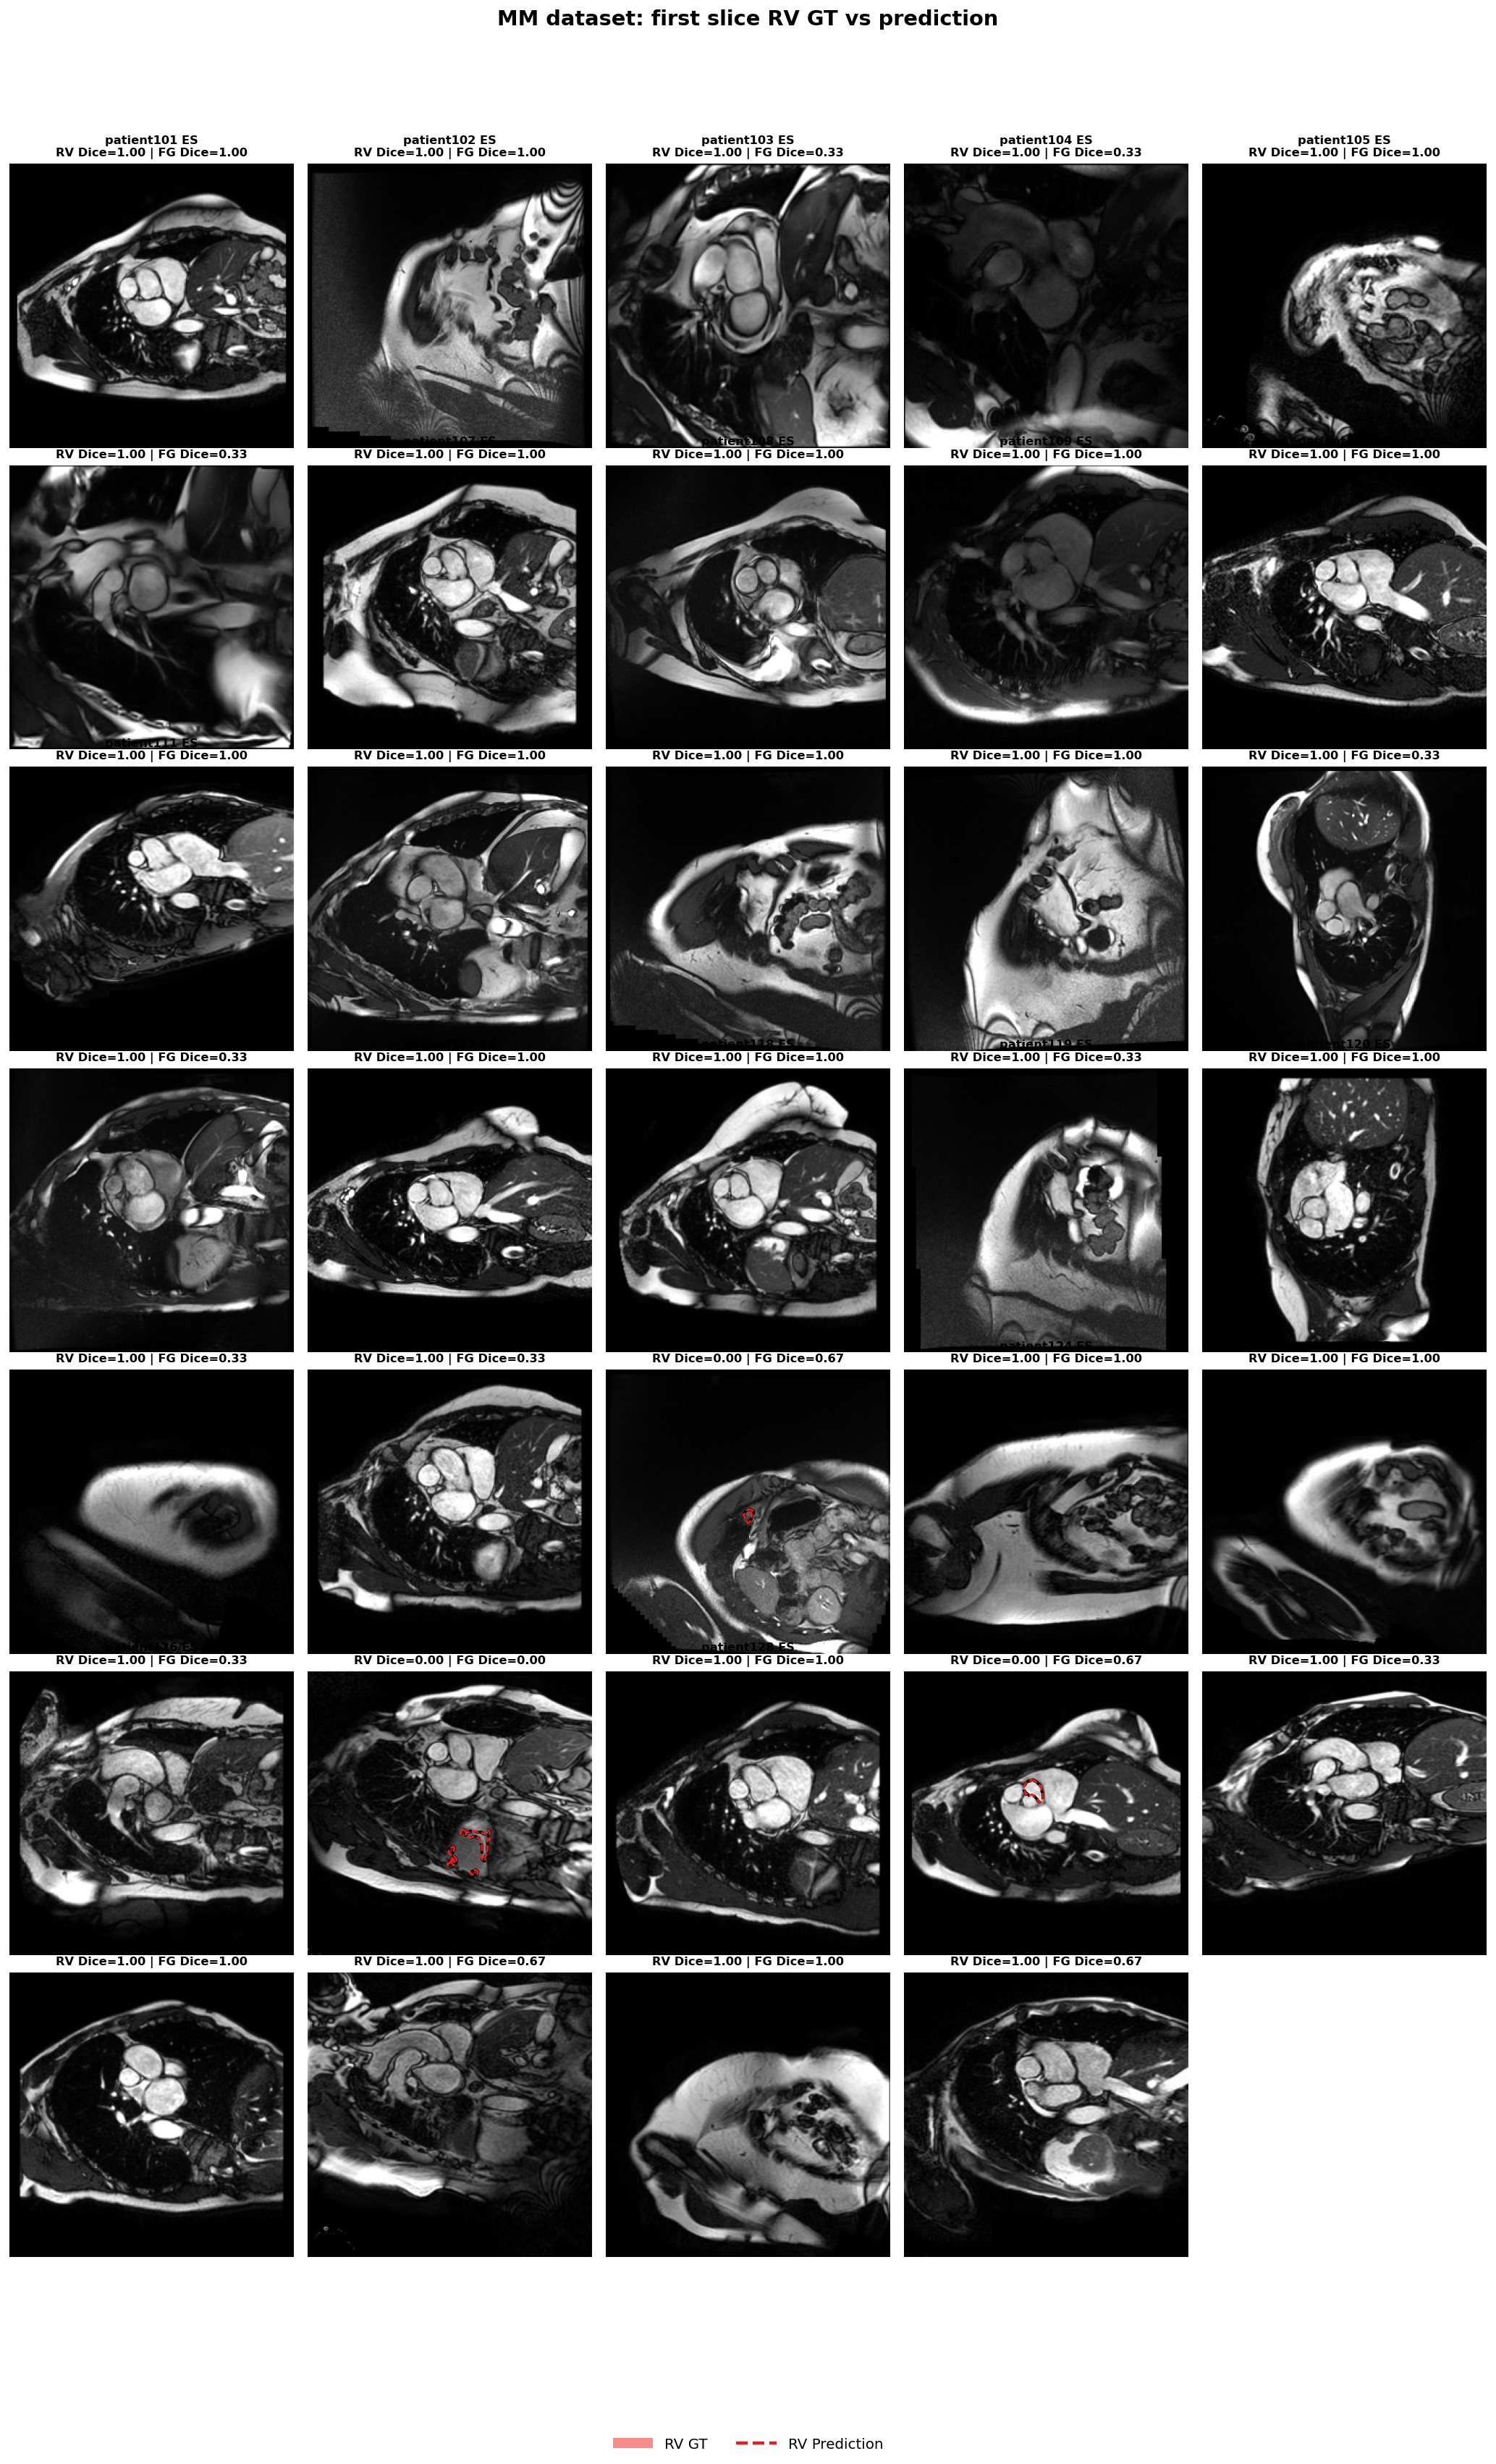

In [83]:
# ---------- MM first slices: RV GT vs prediction ----------
from math import ceil
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

SHOW_RV_PRED_CONTOUR = True
RV_GT_COLOR = "#F51818"
RV_GT_ALPHA = 0.5

mm_first_rows = (
    df[df['dataset'] == 'mm']
    .sort_values(['case_id', 'slice_idx'])
    .groupby('case_id', as_index=False)
    .last()
    .sort_values('case_id')
    .reset_index(drop=True)
)

n_cases = len(mm_first_rows)
ncols = min(5, n_cases)
nrows = ceil(n_cases / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.8 * nrows), dpi=130)
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, mm_first_rows.iterrows()):
    img, gt, pred = load_example_slice(row)

    rv_gt = (gt == 1)
    rv_pred = (pred == 1).astype(float)

    ax.imshow(img, cmap='gray')

    if rv_gt.any():
        gt_rgba = np.zeros((*rv_gt.shape, 4), dtype=float)
        gt_rgba[..., 0] = int(RV_GT_COLOR[1:3], 16) / 255.0
        gt_rgba[..., 1] = int(RV_GT_COLOR[3:5], 16) / 255.0
        gt_rgba[..., 2] = int(RV_GT_COLOR[5:7], 16) / 255.0
        gt_rgba[..., 3] = rv_gt.astype(float) * RV_GT_ALPHA
        ax.imshow(gt_rgba)

    if SHOW_RV_PRED_CONTOUR and rv_pred.any():
        ax.contour(rv_pred, levels=[0.5], colors=['black'], linewidths=2.2, linestyles='--')
        ax.contour(rv_pred, levels=[0.5], colors=[RV_GT_COLOR], linewidths=1.4, linestyles='--')

    ax.set_title(
        f"{row['case_id']} {row['phase']}\nRV Dice={row['dice_c1']:.2f} | FG Dice={row['dice_fg']:.2f}",
        fontsize=9,
        fontweight='bold',
    )
    ax.axis('off')

for ax in axes[n_cases:]:
    ax.axis('off')

legend_handles = [
    Patch(facecolor=(int(RV_GT_COLOR[1:3], 16) / 255.0, int(RV_GT_COLOR[3:5], 16) / 255.0, int(RV_GT_COLOR[5:7], 16) / 255.0, RV_GT_ALPHA), edgecolor='none', label='RV GT'),
]
if SHOW_RV_PRED_CONTOUR:
    legend_handles.append(Line2D([0], [0], color=RV_GT_COLOR, linewidth=2.4, linestyle='--', label='RV Prediction'))

fig.legend(handles=legend_handles, loc='lower center', ncol=len(legend_handles), frameon=False, fontsize=11, handlelength=2.8)
fig.suptitle('MM dataset: first slice RV GT vs prediction', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.subplots_adjust(bottom=0.08, top=0.92)
plt.show()

